# Data loading

In [2]:
import pandas as pd
import pickle
from pathlib import Path

# Get the Code directory (project root)
current_dir = Path.cwd()  # from_scratch directory
code_dir = current_dir.parent.parent.parent.parent  # Go up to Code directory
print(f"Code directory: {code_dir}")

# Define all data paths directly
PATHS = {
    # Training features
    'X_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote.parquet',
    'X_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_tomek.parquet',
    'X_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote_tomek.parquet',
    
    # Training targets
    'y_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote' / 'y_smote.pkl',
    'y_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'tomek' / 'y_tomek.pkl',
    'y_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote_tomek' / 'y_smote_tomek.pkl',
    
    # Validation and test features
    'X_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'X_val.parquet',
    'X_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'X_test.parquet',
    
    # Validation and test targets
    'y_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'y_val.pkl',
    'y_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'y_test.pkl',
}

# Print all paths for verification
print("\nData paths:")
for key, path in PATHS.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {exists} {key}: {path}")

# Load all data
def load_all_data():
    """Load all data files"""
    data = {}
    
    print("\n" + "="*50)
    print("LOADING DATA")
    print("="*50)
    
    # Load parquet files
    parquet_keys = ['X_train_smote', 'X_train_tomek', 'X_train_smote_tomek', 'X_val', 'X_test']
    for key in parquet_keys:
        path = PATHS[key]
        if path.exists():
            try:
                data[key] = pd.read_parquet(path)
                print(f"✓ Loaded {key}: {data[key].shape}")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
        else:
            print(f"✗ Skipping {key}: file not found at {path}")
    
    # Load pickle files
    pickle_keys = ['y_train_smote', 'y_train_tomek', 'y_train_smote_tomek', 'y_val', 'y_test']
    for key in pickle_keys:
        path = PATHS[key]
        if path.exists():
            try:
                with open(path, 'rb') as f:
                    data[key] = pickle.load(f)
                print(f"✓ Loaded {key}: {len(data[key])} samples")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
        else:
            print(f"✗ Skipping {key}: file not found at {path}")
    
    return data

# Load the data
data = load_all_data()

if data:
    print(f"\n" + "="*50)
    print(f"Successfully loaded {len(data)} datasets")
    print("="*50)
    for key, value in data.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {value.shape}")
        else:
            print(f"  {key}: {len(value)} samples")
else:
    print("\nNo data was loaded")

Code directory: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code

Data paths:
  ✓ X_train_smote: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_smote.parquet
  ✓ X_train_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_tomek.parquet
  ✓ X_train_smote_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_smote_tomek.parquet
  ✓ y_train_smote: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Resampled_Data_split\smote\y_smote.pkl
  ✓ y_train_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Resampled_Data_split\tomek\y_tomek.pkl
  ✓ y_train_smote_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessi

# Clarans predefined

Code directory: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code

LOADING DATA
✓ Loaded X_train_smote: (30570, 64)
✓ Loaded X_train_tomek: (15911, 64)
✓ Loaded X_train_smote_tomek: (30266, 64)
✓ Loaded X_val: (3477, 64)
✓ Loaded X_test: (3477, 64)
✓ Loaded y_train_smote: 30570 samples
✓ Loaded y_train_tomek: 15911 samples
✓ Loaded y_train_smote_tomek: 30266 samples
✓ Loaded y_val: 3477 samples
✓ Loaded y_test: 3477 samples

FINDING OPTIMAL K (using CLARA)

Testing k=2...
  Silhouette: 0.9711
  Davies-Bouldin: 0.0301
  Calinski-Harabasz: 458267.6559
  ARI: 0.0127

Testing k=3...
  Silhouette: 0.6791
  Davies-Bouldin: 0.3226
  Calinski-Harabasz: 574914.1695
  ARI: 0.0230

Testing k=4...
  Silhouette: 0.5353
  Davies-Bouldin: 0.7200
  Calinski-Harabasz: 486408.5876
  ARI: 0.0250


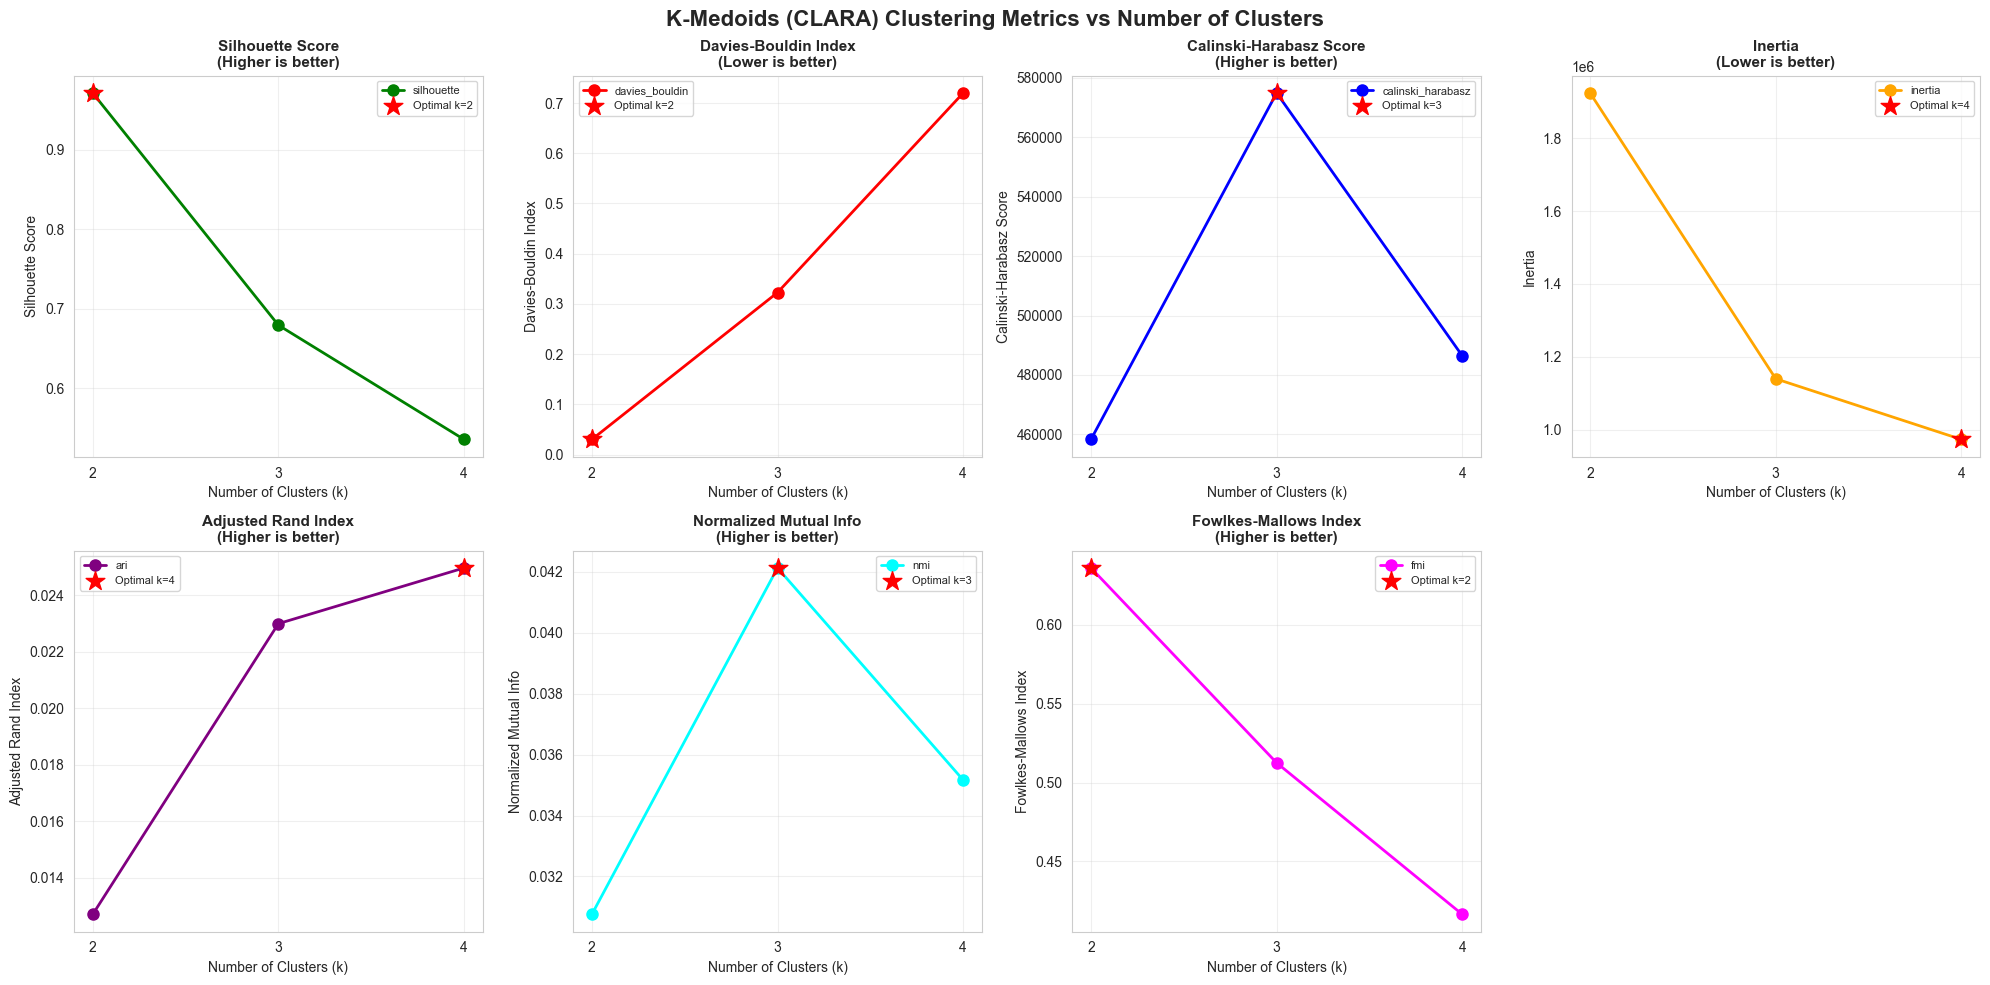


Optimal k for SMOTE: 2

CLUSTERING: SMOTE (k=2)

Running CLARA with 5 samplings of 2000 samples each...
  Sampling 1/5: cost = 19609607.26
  Sampling 2/5: cost = 19605586.55
  Sampling 3/5: cost = 19608976.14
  Sampling 4/5: cost = 19599672.39
  Sampling 5/5: cost = 19599265.36
Best cost: 19599265.36

Calculating metrics on full dataset...

Clustering Metrics:
  Silhouette Score: 0.9710
  Davies-Bouldin Index: 0.0300
  Calinski-Harabasz Score: 4629781.2201
  Inertia: 19599265.3598
  Adjusted Rand Index: 0.0149
  Normalized Mutual Info: 0.0345
  Fowlkes-Mallows Score: 0.6336

Generating visualizations for SMOTE...
Sampling 10,000 points for visualization...


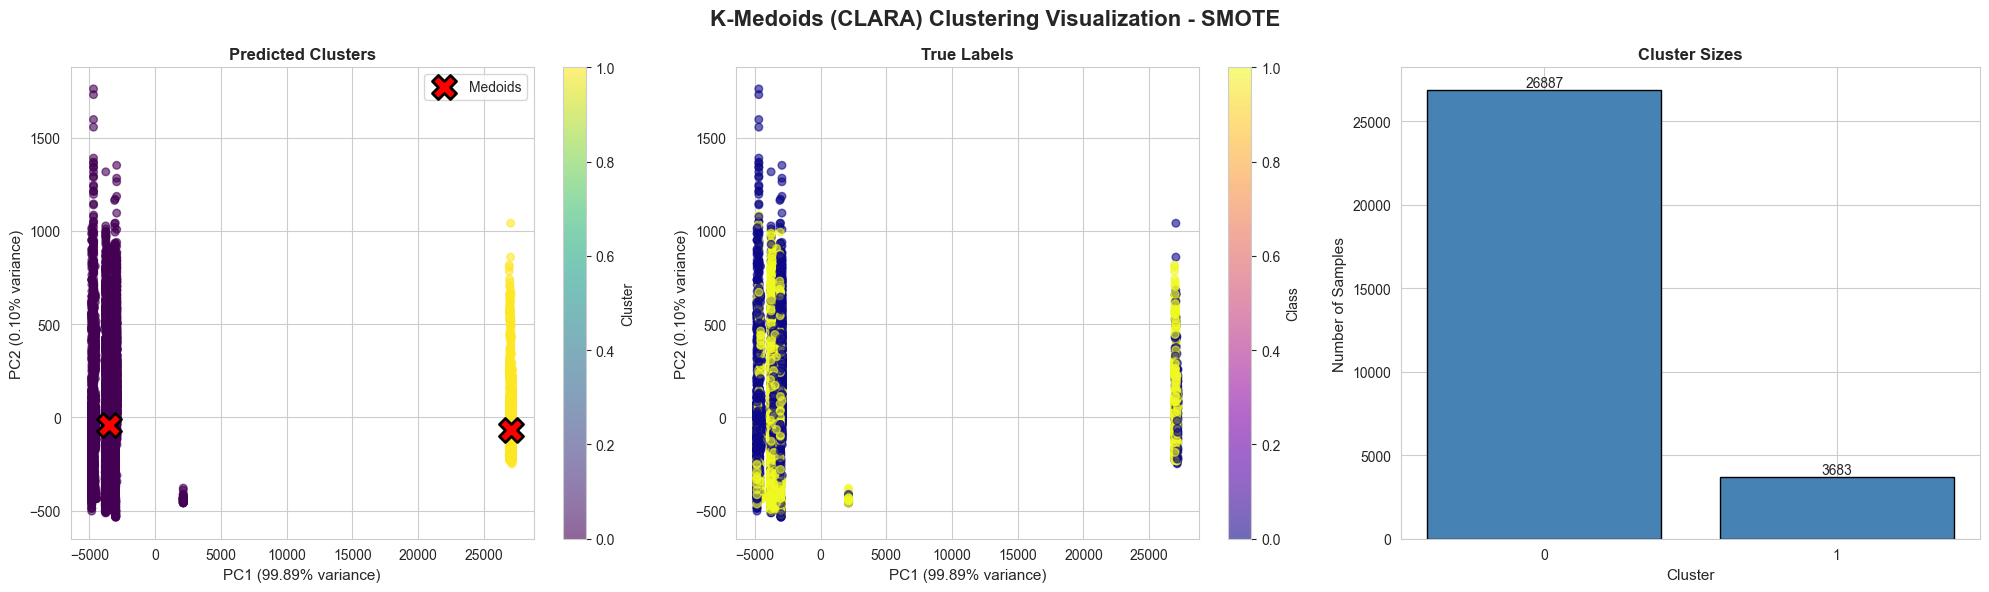


FINDING OPTIMAL K (using CLARA)

Testing k=2...
  Silhouette: 0.9694
  Davies-Bouldin: 0.0311
  Calinski-Harabasz: 265918.5293
  ARI: 0.0864

Testing k=3...
  Silhouette: 0.7163
  Davies-Bouldin: 0.2871
  Calinski-Harabasz: 547820.3351
  ARI: 0.0025

Testing k=4...
  Silhouette: 0.5706
  Davies-Bouldin: 0.5876
  Calinski-Harabasz: 508135.2023
  ARI: 0.0175


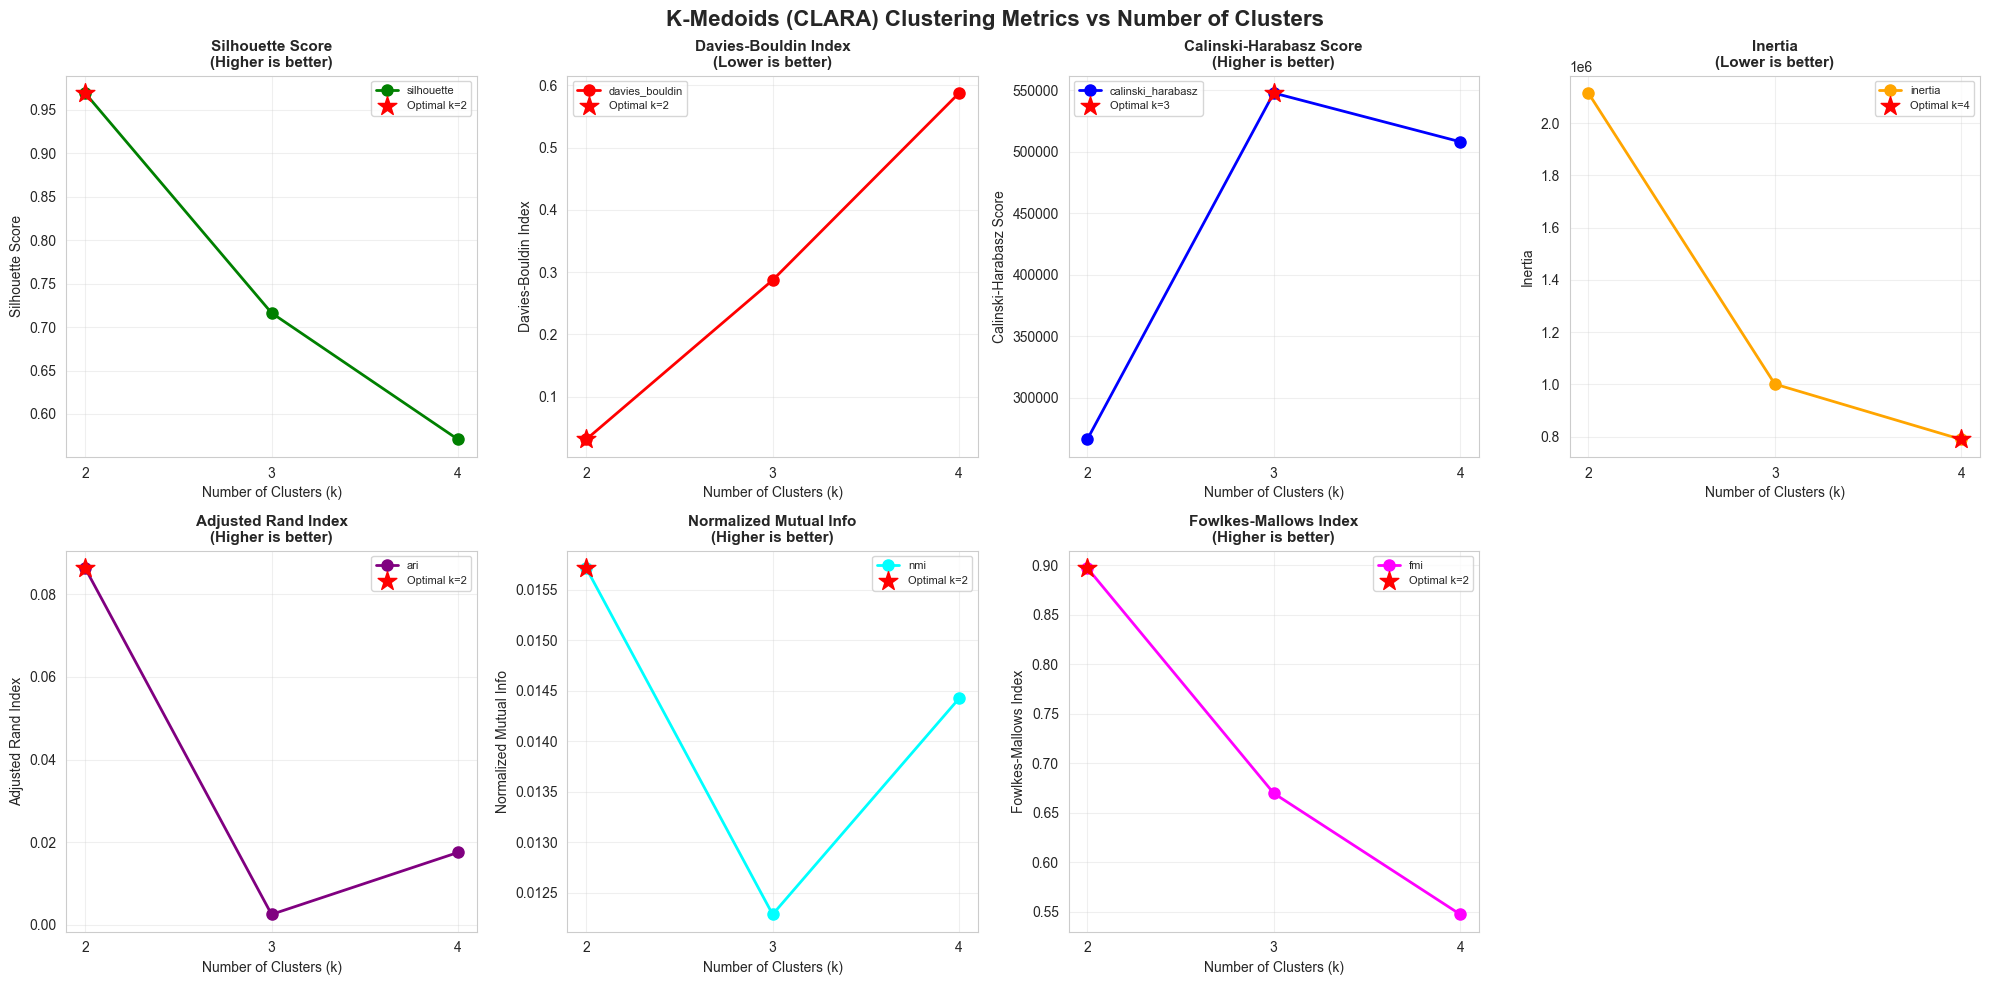


Optimal k for Tomek: 2

CLUSTERING: Tomek (k=2)

Running CLARA with 5 samplings of 2000 samples each...
  Sampling 1/5: cost = 11232019.98
  Sampling 2/5: cost = 11261779.54
  Sampling 3/5: cost = 11229284.35
  Sampling 4/5: cost = 11236585.40
  Sampling 5/5: cost = 11229476.22
Best cost: 11229284.35

Calculating metrics on full dataset...

Clustering Metrics:
  Silhouette Score: 0.9693
  Davies-Bouldin Index: 0.0316
  Calinski-Harabasz Score: 1358295.6652
  Inertia: 11229284.3516
  Adjusted Rand Index: 0.1080
  Normalized Mutual Info: 0.0228
  Fowlkes-Mallows Score: 0.8967

Generating visualizations for Tomek...
Sampling 10,000 points for visualization...


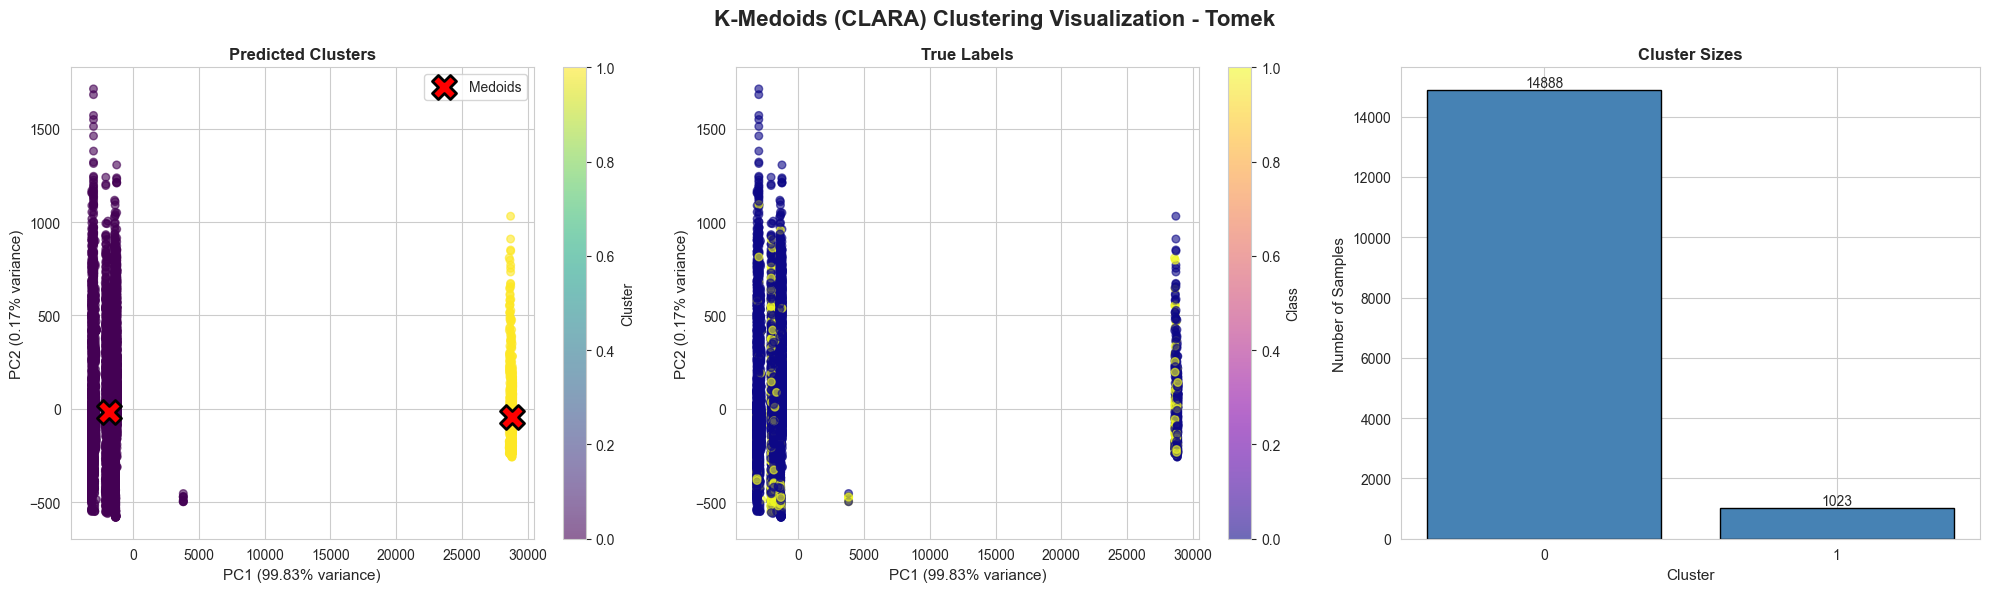


FINDING OPTIMAL K (using CLARA)

Testing k=2...
  Silhouette: 0.9711
  Davies-Bouldin: 0.0302
  Calinski-Harabasz: 470223.5396
  ARI: 0.0140

Testing k=3...
  Silhouette: 0.6695
  Davies-Bouldin: 0.3355
  Calinski-Harabasz: 532586.2433
  ARI: 0.0206

Testing k=4...
  Silhouette: 0.5430
  Davies-Bouldin: 0.6655
  Calinski-Harabasz: 467548.8134
  ARI: 0.0543


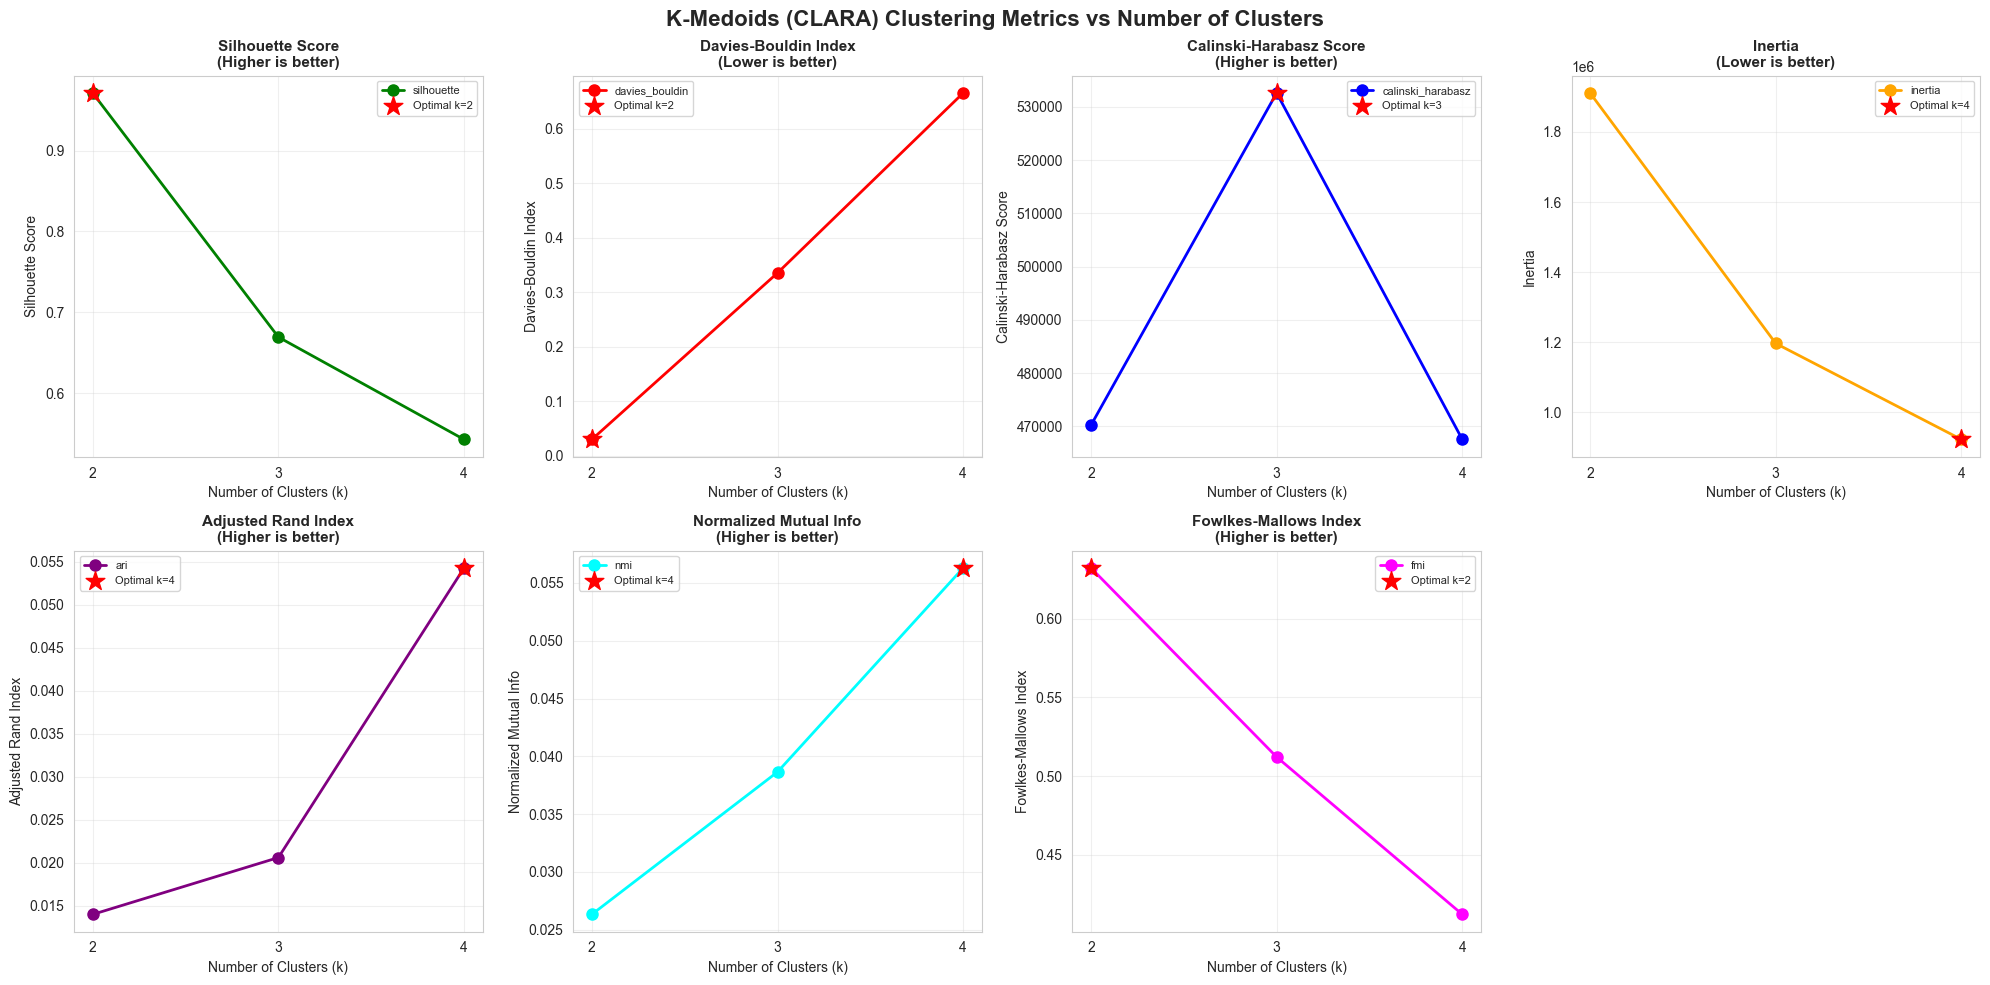


Optimal k for SMOTE-Tomek: 2

CLUSTERING: SMOTE-Tomek (k=2)

Running CLARA with 5 samplings of 2000 samples each...
  Sampling 1/5: cost = 19376137.45
  Sampling 2/5: cost = 19418134.42
  Sampling 3/5: cost = 19378019.19
  Sampling 4/5: cost = 19388596.19
  Sampling 5/5: cost = 19398136.99
Best cost: 19376137.45

Calculating metrics on full dataset...

Clustering Metrics:
  Silhouette Score: 0.9710
  Davies-Bouldin Index: 0.0300
  Calinski-Harabasz Score: 4600914.9585
  Inertia: 19376137.4526
  Adjusted Rand Index: 0.0152
  Normalized Mutual Info: 0.0351
  Fowlkes-Mallows Score: 0.6335

Generating visualizations for SMOTE-Tomek...
Sampling 10,000 points for visualization...


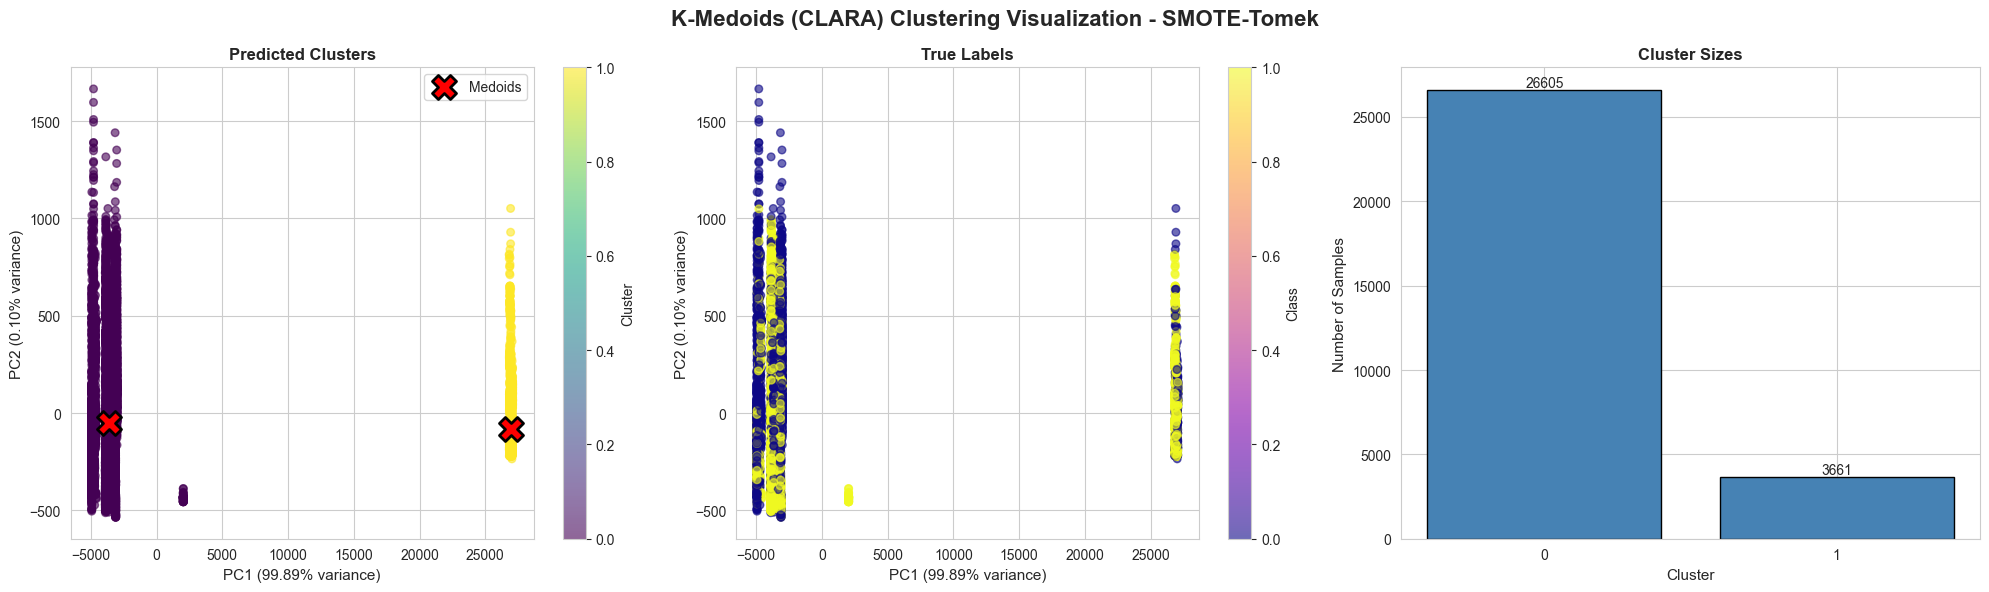


COMPARING DATASETS

              Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Score  \
SMOTE                0.970964              0.030009             4.629781e+06   
Tomek                0.969346              0.031577             1.358296e+06   
SMOTE-Tomek          0.970994              0.029986             4.600915e+06   

                  Inertia  Adjusted Rand Index  Normalized Mutual Info  \
SMOTE        1.959927e+07             0.014874                0.034501   
Tomek        1.122928e+07             0.108034                0.022813   
SMOTE-Tomek  1.937614e+07             0.015174                0.035063   

             Fowlkes-Mallows Score  
SMOTE                     0.633635  
Tomek                     0.896690  
SMOTE-Tomek               0.633465  


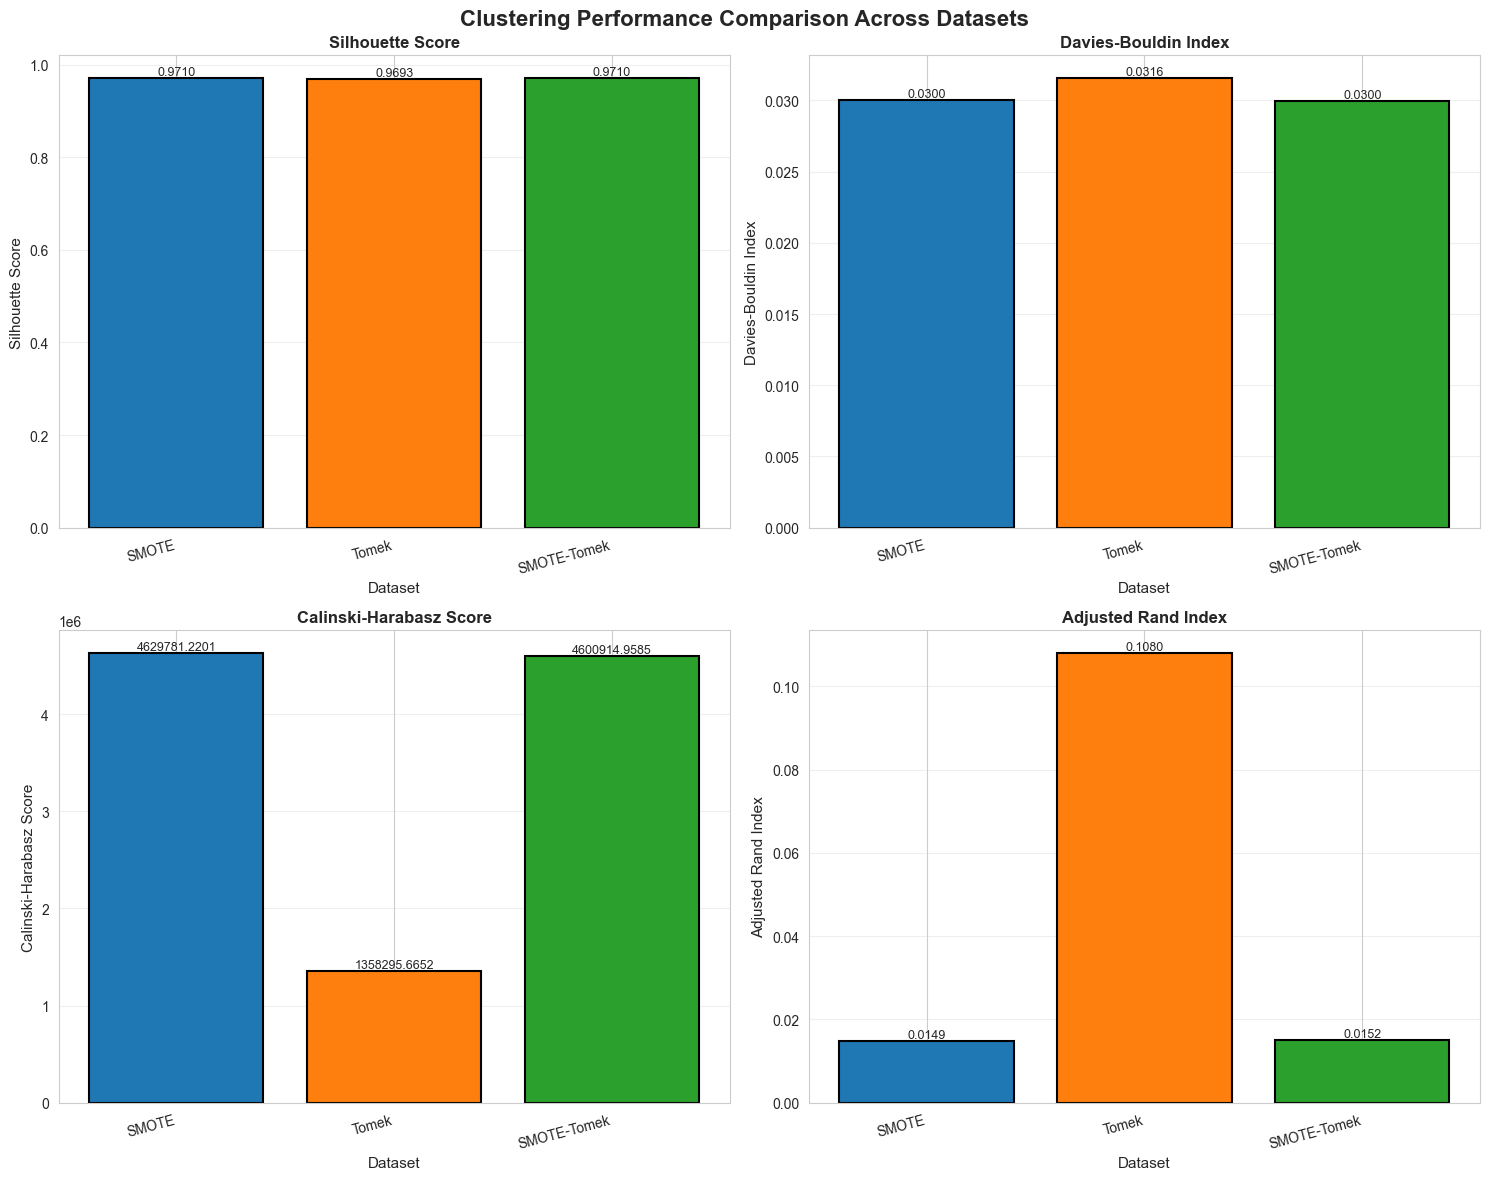


ANALYSIS COMPLETE


In [10]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import MiniBatchKMeans
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Get the Code directory (project root)
current_dir = Path.cwd()
code_dir = current_dir.parent.parent.parent.parent
print(f"Code directory: {code_dir}")

# Define all data paths
PATHS = {
    'X_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote.parquet',
    'X_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_tomek.parquet',
    'X_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote_tomek.parquet',
    'y_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote' / 'y_smote.pkl',
    'y_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'tomek' / 'y_tomek.pkl',
    'y_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote_tomek' / 'y_smote_tomek.pkl',
    'X_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'X_val.parquet',
    'X_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'X_test.parquet',
    'y_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'y_val.pkl',
    'y_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'y_test.pkl',
}

class CLARA:
    """CLARA (Clustering Large Applications) - Memory-efficient K-Medoids"""
    def __init__(self, n_clusters, n_sampling=5, sample_size=1000, random_state=42):
        self.n_clusters = n_clusters
        self.n_sampling = n_sampling
        self.sample_size = sample_size
        self.random_state = random_state
        self.best_medoid_indices_ = None
        self.labels_ = None
        self.inertia_ = None
        
    def fit(self, X):
        """Fit CLARA algorithm"""
        np.random.seed(self.random_state)
        best_cost = np.inf
        
        # Convert to numpy array and ensure float64
        if isinstance(X, pd.DataFrame):
            X_array = X.values.astype(np.float64)
        else:
            X_array = np.asarray(X, dtype=np.float64)
        
        print(f"\nRunning CLARA with {self.n_sampling} samplings of {self.sample_size} samples each...")
        
        for i in range(self.n_sampling):
            # Sample data
            sample_idx = np.random.choice(len(X_array), 
                                         min(self.sample_size, len(X_array)), 
                                         replace=False)
            X_sample = X_array[sample_idx]
            
            # Run K-Medoids on sample
            kmedoids = KMedoids(
                n_clusters=self.n_clusters,
                metric='euclidean',
                method='pam',
                init='k-medoids++',
                max_iter=300,
                random_state=self.random_state + i
            )
            kmedoids.fit(X_sample)
            
            # Get medoids from sample
            sample_medoid_indices = kmedoids.medoid_indices_
            medoids = X_sample[sample_medoid_indices].astype(np.float64)
            
            # Assign all data points to nearest medoid using chunked processing
            labels = np.zeros(len(X_array), dtype=np.int32)
            min_distances = np.full(len(X_array), np.inf, dtype=np.float64)
            
            chunk_size = 5000
            for start_idx in range(0, len(X_array), chunk_size):
                end_idx = min(start_idx + chunk_size, len(X_array))
                X_chunk = X_array[start_idx:end_idx]
                
                # Calculate distances for this chunk
                chunk_distances = np.zeros((len(X_chunk), self.n_clusters), dtype=np.float64)
                for j, medoid in enumerate(medoids):
                    diff = X_chunk - medoid
                    chunk_distances[:, j] = np.sqrt(np.sum(diff ** 2, axis=1))
                
                labels[start_idx:end_idx] = np.argmin(chunk_distances, axis=1)
                min_distances[start_idx:end_idx] = np.min(chunk_distances, axis=1)
            
            cost = np.sum(min_distances)
            
            # Update best solution
            if cost < best_cost:
                best_cost = cost
                # Find actual indices of medoids in full dataset
                self.best_medoid_indices_ = []
                for medoid in medoids:
                    # Find closest point in full dataset to this medoid
                    diff = X_array - medoid
                    distances_to_medoid = np.sqrt(np.sum(diff ** 2, axis=1))
                    self.best_medoid_indices_.append(np.argmin(distances_to_medoid))
                self.labels_ = labels.copy()
                self.inertia_ = cost
            
            print(f"  Sampling {i+1}/{self.n_sampling}: cost = {cost:.2f}")
        
        self.best_medoid_indices_ = np.array(self.best_medoid_indices_)
        print(f"Best cost: {best_cost:.2f}")
        return self
    
    def fit_predict(self, X):
        """Fit and return labels"""
        self.fit(X)
        return self.labels_
    
    @property
    def medoid_indices_(self):
        return self.best_medoid_indices_

def load_all_data():
    """Load all data files"""
    data = {}
    print("\n" + "="*50)
    print("LOADING DATA")
    print("="*50)
    
    parquet_keys = ['X_train_smote', 'X_train_tomek', 'X_train_smote_tomek', 'X_val', 'X_test']
    for key in parquet_keys:
        path = PATHS[key]
        if path.exists():
            try:
                data[key] = pd.read_parquet(path)
                print(f"✓ Loaded {key}: {data[key].shape}")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
    
    pickle_keys = ['y_train_smote', 'y_train_tomek', 'y_train_smote_tomek', 'y_val', 'y_test']
    for key in pickle_keys:
        path = PATHS[key]
        if path.exists():
            try:
                with open(path, 'rb') as f:
                    data[key] = pickle.load(f)
                print(f"✓ Loaded {key}: {len(data[key])} samples")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
    
    return data

def find_optimal_k(X, y_true, k_range=range(2, 5), max_samples=3000):
    """Find optimal number of clusters using various metrics"""
    print("\n" + "="*50)
    print(f"FINDING OPTIMAL K (using CLARA)")
    print("="*50)
    
    # Sample data for faster computation
    if len(X) > max_samples:
        sample_idx = np.random.choice(len(X), max_samples, replace=False)
        X_sample = X.iloc[sample_idx] if isinstance(X, pd.DataFrame) else X[sample_idx]
        y_sample = y_true.iloc[sample_idx] if isinstance(y_true, pd.Series) else y_true[sample_idx]
    else:
        X_sample = X
        y_sample = y_true
    
    metrics = {
        'k': [],
        'silhouette': [],
        'davies_bouldin': [],
        'calinski_harabasz': [],
        'inertia': [],
        'ari': [],
        'nmi': [],
        'fmi': []
    }
    
    for k in k_range:
        print(f"\nTesting k={k}...")
        
        # Use CLARA for large datasets
        if len(X_sample) > 5000:
            clara = CLARA(n_clusters=k, n_sampling=3, sample_size=1000, random_state=42)
            labels = clara.fit_predict(X_sample)
            inertia = clara.inertia_
        else:
            # Use regular K-Medoids for smaller samples
            kmedoids = KMedoids(
                n_clusters=k,
                metric='euclidean',
                method='pam',
                init='k-medoids++',
                max_iter=300,
                random_state=42
            )
            labels = kmedoids.fit_predict(X_sample)
            inertia = kmedoids.inertia_
        
        # Calculate metrics
        metrics['k'].append(k)
        metrics['silhouette'].append(silhouette_score(X_sample, labels))
        metrics['davies_bouldin'].append(davies_bouldin_score(X_sample, labels))
        metrics['calinski_harabasz'].append(calinski_harabasz_score(X_sample, labels))
        metrics['inertia'].append(inertia)
        
        # External validation metrics
        metrics['ari'].append(adjusted_rand_score(y_sample, labels))
        metrics['nmi'].append(normalized_mutual_info_score(y_sample, labels))
        metrics['fmi'].append(fowlkes_mallows_score(y_sample, labels))
        
        print(f"  Silhouette: {metrics['silhouette'][-1]:.4f}")
        print(f"  Davies-Bouldin: {metrics['davies_bouldin'][-1]:.4f}")
        print(f"  Calinski-Harabasz: {metrics['calinski_harabasz'][-1]:.4f}")
        print(f"  ARI: {metrics['ari'][-1]:.4f}")
    
    return pd.DataFrame(metrics)

def plot_metrics(metrics_df, save_path=None):
    """Plot clustering metrics for different k values"""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('K-Medoids (CLARA) Clustering Metrics vs Number of Clusters', 
                 fontsize=16, fontweight='bold')
    
    plot_configs = [
        ('silhouette', 'Silhouette Score', 'Higher is better', 'green'),
        ('davies_bouldin', 'Davies-Bouldin Index', 'Lower is better', 'red'),
        ('calinski_harabasz', 'Calinski-Harabasz Score', 'Higher is better', 'blue'),
        ('inertia', 'Inertia', 'Lower is better', 'orange'),
        ('ari', 'Adjusted Rand Index', 'Higher is better', 'purple'),
        ('nmi', 'Normalized Mutual Info', 'Higher is better', 'cyan'),
        ('fmi', 'Fowlkes-Mallows Index', 'Higher is better', 'magenta'),
    ]
    
    for idx, (metric, title, subtitle, color) in enumerate(plot_configs):
        ax = axes[idx // 4, idx % 4]
        ax.plot(metrics_df['k'], metrics_df[metric], marker='o', linewidth=2, 
                markersize=8, color=color, label=metric)
        ax.set_xlabel('Number of Clusters (k)', fontsize=10)
        ax.set_ylabel(title, fontsize=10)
        ax.set_title(f'{title}\n({subtitle})', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(metrics_df['k'])
        
        # Mark optimal point
        if 'lower' in subtitle.lower():
            optimal_idx = metrics_df[metric].idxmin()
        else:
            optimal_idx = metrics_df[metric].idxmax()
        optimal_k = metrics_df.loc[optimal_idx, 'k']
        optimal_val = metrics_df.loc[optimal_idx, metric]
        ax.scatter([optimal_k], [optimal_val], color='red', s=200, marker='*', 
                  zorder=5, label=f'Optimal k={optimal_k}')
        ax.legend(loc='best', fontsize=8)
    
    # Remove extra subplot
    fig.delaxes(axes[1, 3])
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def perform_clustering(X, y_true, n_clusters, dataset_name='Dataset'):
    """Perform K-Medoids clustering using CLARA for large datasets"""
    print("\n" + "="*50)
    print(f"CLUSTERING: {dataset_name} (k={n_clusters})")
    print("="*50)
    
    # Use CLARA for large datasets
    clara = CLARA(
        n_clusters=n_clusters, 
        n_sampling=5,  # Number of sampling iterations
        sample_size=2000,  # Size of each sample
        random_state=42
    )
    
    labels = clara.fit_predict(X)
    
    # Calculate metrics on full dataset
    print("\nCalculating metrics on full dataset...")
    metrics = {
        'Silhouette Score': silhouette_score(X, labels),
        'Davies-Bouldin Index': davies_bouldin_score(X, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(X, labels),
        'Inertia': clara.inertia_,
        'Adjusted Rand Index': adjusted_rand_score(y_true, labels),
        'Normalized Mutual Info': normalized_mutual_info_score(y_true, labels),
        'Fowlkes-Mallows Score': fowlkes_mallows_score(y_true, labels)
    }
    
    print("\nClustering Metrics:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    
    return clara, labels, metrics

def visualize_clusters(X, labels, y_true, medoids_idx, dataset_name='Dataset', save_path=None):
    """Visualize clusters using PCA"""
    print(f"\nGenerating visualizations for {dataset_name}...")
    
    # Sample data for visualization if too large
    if len(X) > 10000:
        print(f"Sampling 10,000 points for visualization...")
        sample_idx = np.random.choice(len(X), 10000, replace=False)
        X_vis = X.iloc[sample_idx] if isinstance(X, pd.DataFrame) else X[sample_idx]
        labels_vis = labels[sample_idx]
        y_vis = y_true.iloc[sample_idx] if isinstance(y_true, pd.Series) else y_true[sample_idx]
    else:
        X_vis = X
        labels_vis = labels
        y_vis = y_true
    
    # Apply PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vis)
    
    # Transform medoids
    X_array = X.values if isinstance(X, pd.DataFrame) else X
    medoids_pca = pca.transform(X_array[medoids_idx])
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'K-Medoids (CLARA) Clustering Visualization - {dataset_name}', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: Predicted clusters
    scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_vis, 
                               cmap='viridis', alpha=0.6, s=30)
    axes[0].scatter(medoids_pca[:, 0], medoids_pca[:, 1], 
                   c='red', marker='X', s=300, edgecolors='black', 
                   linewidths=2, label='Medoids')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
    axes[0].set_title('Predicted Clusters', fontsize=12, fontweight='bold')
    axes[0].legend()
    plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    
    # Plot 2: True labels
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_vis, 
                               cmap='plasma', alpha=0.6, s=30)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
    axes[1].set_title('True Labels', fontsize=12, fontweight='bold')
    plt.colorbar(scatter2, ax=axes[1], label='Class')
    
    # Plot 3: Cluster sizes
    unique_labels, counts = np.unique(labels, return_counts=True)
    axes[2].bar(unique_labels, counts, color='steelblue', edgecolor='black')
    axes[2].set_xlabel('Cluster', fontsize=11)
    axes[2].set_ylabel('Number of Samples', fontsize=11)
    axes[2].set_title('Cluster Sizes', fontsize=12, fontweight='bold')
    axes[2].set_xticks(unique_labels)
    for i, (label, count) in enumerate(zip(unique_labels, counts)):
        axes[2].text(label, count, str(count), ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def compare_datasets(all_results):
    """Compare clustering results across datasets"""
    print("\n" + "="*50)
    print("COMPARING DATASETS")
    print("="*50)
    
    comparison = pd.DataFrame(all_results).T
    print("\n", comparison)
    
    metrics_to_plot = ['Silhouette Score', 'Davies-Bouldin Index', 
                       'Calinski-Harabasz Score', 'Adjusted Rand Index']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Clustering Performance Comparison Across Datasets', 
                 fontsize=16, fontweight='bold')
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        values = comparison[metric]
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        bars = ax.bar(range(len(values)), values, color=colors, edgecolor='black', linewidth=1.5)
        ax.set_xlabel('Dataset', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(values)))
        ax.set_xticklabels(values.index, rotation=15, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('clustering_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Main execution
if __name__ == "__main__":
    data = load_all_data()
    
    if not data:
        print("No data loaded. Exiting.")
        exit()
    
    datasets = [
        ('X_train_smote', 'y_train_smote', 'SMOTE'),
        ('X_train_tomek', 'y_train_tomek', 'Tomek'),
        ('X_train_smote_tomek', 'y_train_smote_tomek', 'SMOTE-Tomek')
    ]
    
    all_results = {}
    
    for X_key, y_key, name in datasets:
        if X_key in data and y_key in data:
            X = data[X_key]
            y = data[y_key]
            
            # Find optimal k
            metrics_df = find_optimal_k(X, y, k_range=range(2, 5))
            plot_metrics(metrics_df, save_path=f'metrics_{name.lower()}.png')
            
            # Use optimal k based on silhouette score
            optimal_k = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k']
            print(f"\nOptimal k for {name}: {int(optimal_k)}")
            
            # Perform clustering with optimal k
            model, labels, metrics = perform_clustering(X, y, int(optimal_k), name)
            
            # Visualize
            visualize_clusters(X, labels, y, model.medoid_indices_, 
                             name, save_path=f'clusters_{name.lower()}.png')
            
            all_results[name] = metrics
    
    if all_results:
        compare_datasets(all_results)
    
    print("\n" + "="*50)
    print("ANALYSIS COMPLETE")
    print("="*50)

# Bayesian Search

Code directory: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code

LOADING DATA
✓ Loaded X_train_smote: (30570, 64)
✓ Loaded X_train_tomek: (15911, 64)
✓ Loaded X_train_smote_tomek: (30266, 64)
✓ Loaded y_train_smote: 30570 samples
✓ Loaded y_train_tomek: 15911 samples
✓ Loaded y_train_smote_tomek: 30266 samples

PROCESSING: SMOTE

BAYESIAN OPTIMIZATION: SMOTE
Sampling 3000 points for optimization...

Starting Bayesian Optimization with 30 iterations...

Iteration 1:
  n_clusters=8, n_sampling=3, sample_size=1670
  Silhouette: 0.5696, ARI: 0.0433, NMI: 0.0658

Iteration 2:
  n_clusters=7, n_sampling=5, sample_size=650
  Silhouette: 0.5499, ARI: 0.0434, NMI: 0.0621

Iteration 3:
  n_clusters=6, n_sampling=4, sample_size=714
  Silhouette: 0.5724, ARI: 0.0516, NMI: 0.0644

Iteration 4:
  n_clusters=7, n_sampling=2, sample_size=1583
  Silhouette: 0.5918, ARI: 0.0518, NMI: 0.0659

Iteration 5:
  n_clusters=10, n_sampling=2, sample_size=1988
  Silhouette: 0.5167, ARI: 0.038

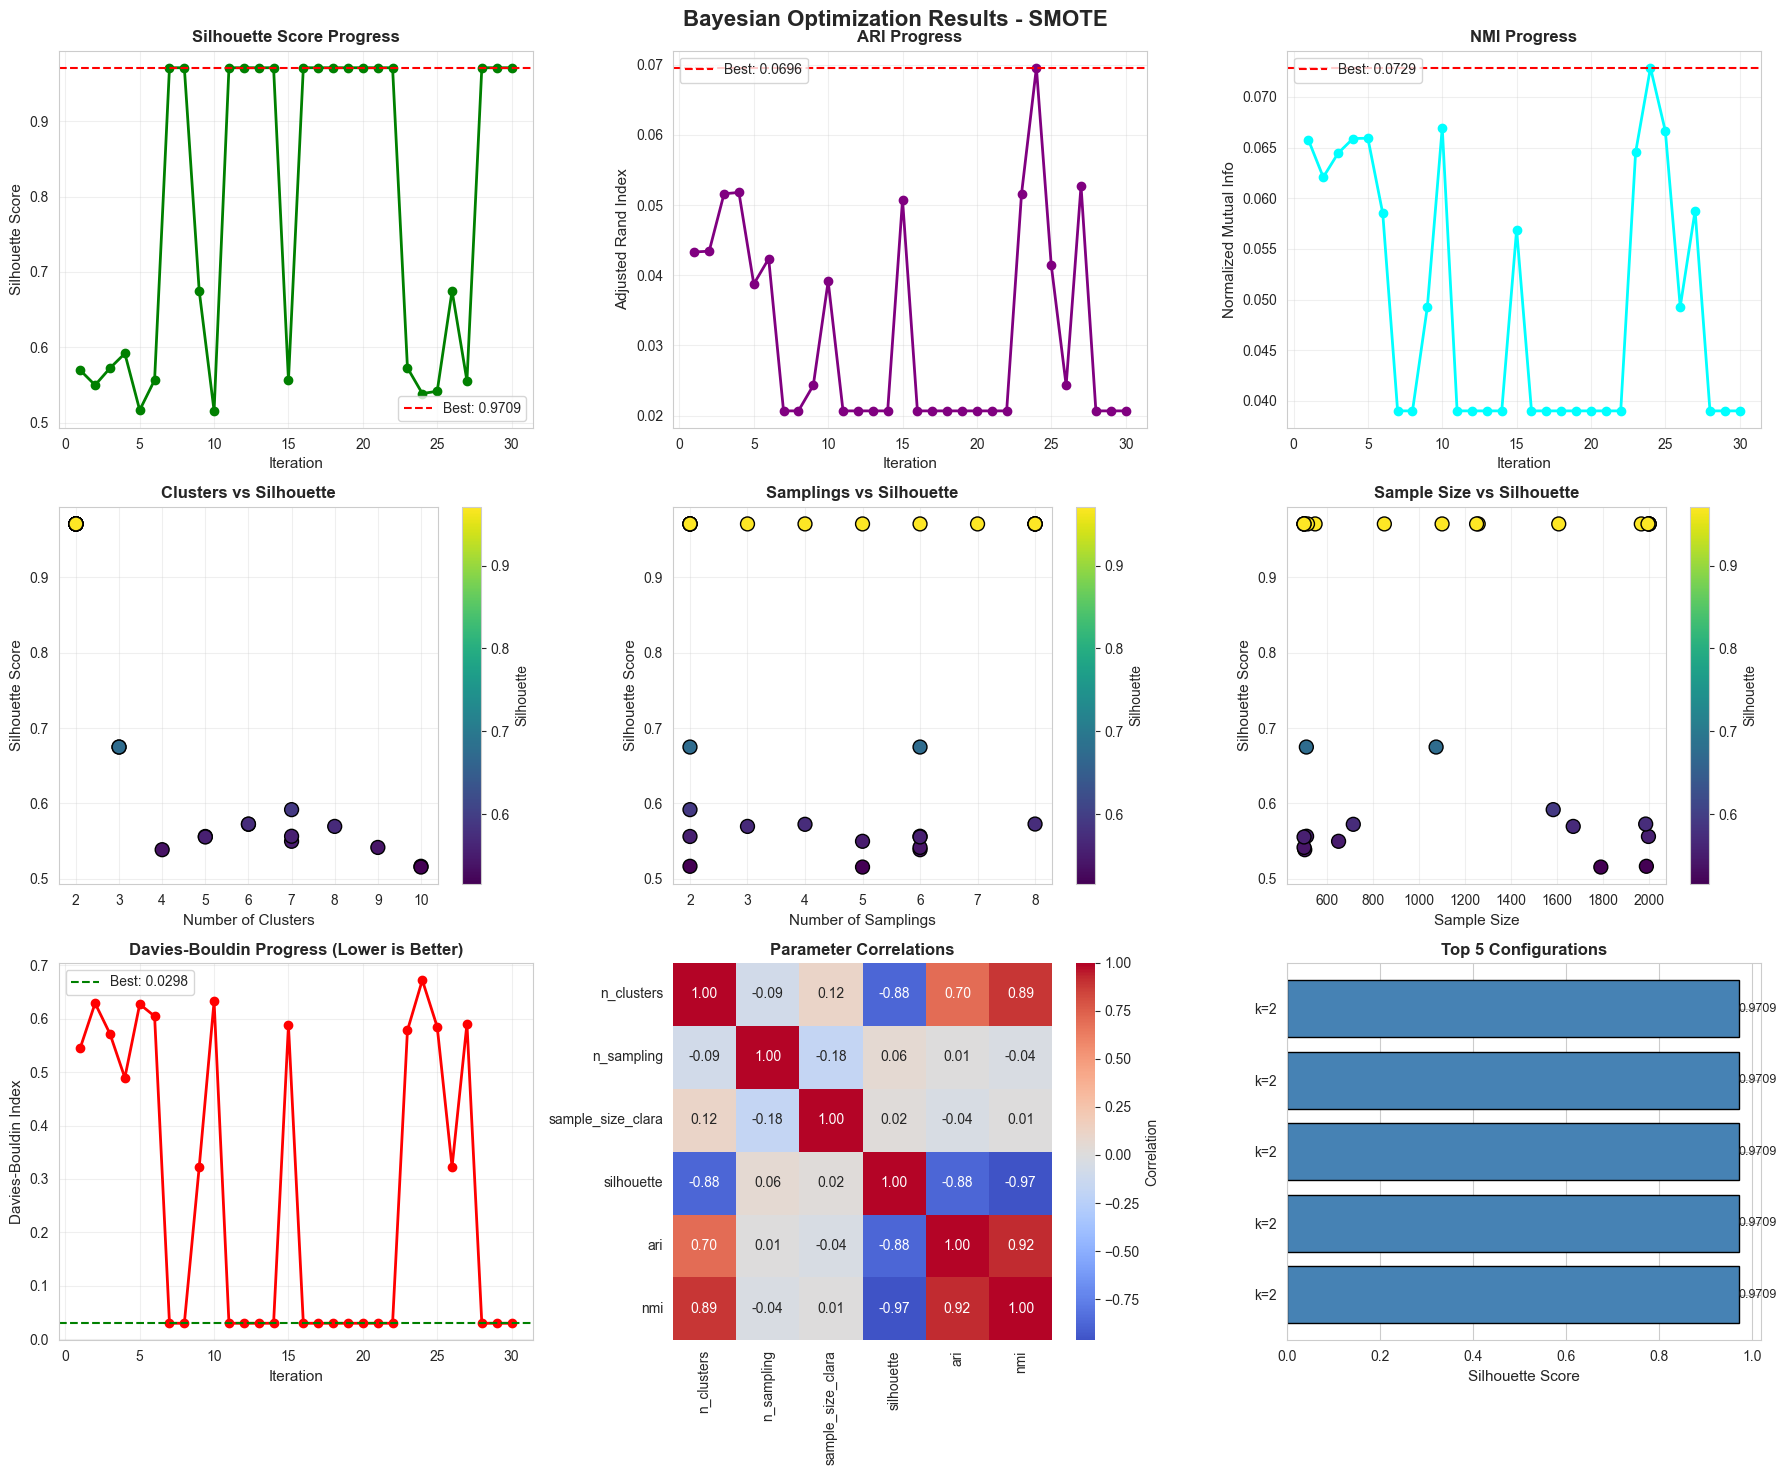


TRAINING FINAL MODEL: SMOTE
Fitting on full dataset...

Final Model Metrics:
  Silhouette Score: 0.9710
  Davies-Bouldin Index: 0.0300
  Calinski-Harabasz Score: 4629781.2201
  Inertia: 19601927.6512
  Adjusted Rand Index: 0.0149
  Normalized Mutual Info: 0.0345
  Fowlkes-Mallows Score: 0.6336

Model saved to 'clara_model_smote.pkl'

PROCESSING: Tomek

BAYESIAN OPTIMIZATION: Tomek
Sampling 3000 points for optimization...

Starting Bayesian Optimization with 30 iterations...

Iteration 1:
  n_clusters=8, n_sampling=3, sample_size=1670
  Silhouette: 0.5589, ARI: 0.0080, NMI: 0.0161

Iteration 2:
  n_clusters=7, n_sampling=5, sample_size=650
  Silhouette: 0.5589, ARI: 0.0051, NMI: 0.0142

Iteration 3:
  n_clusters=6, n_sampling=4, sample_size=714
  Silhouette: 0.6055, ARI: 0.0094, NMI: 0.0154

Iteration 4:
  n_clusters=7, n_sampling=2, sample_size=1583
  Silhouette: 0.5527, ARI: 0.0048, NMI: 0.0137

Iteration 5:
  n_clusters=10, n_sampling=2, sample_size=1988
  Silhouette: 0.4655, ARI: 0

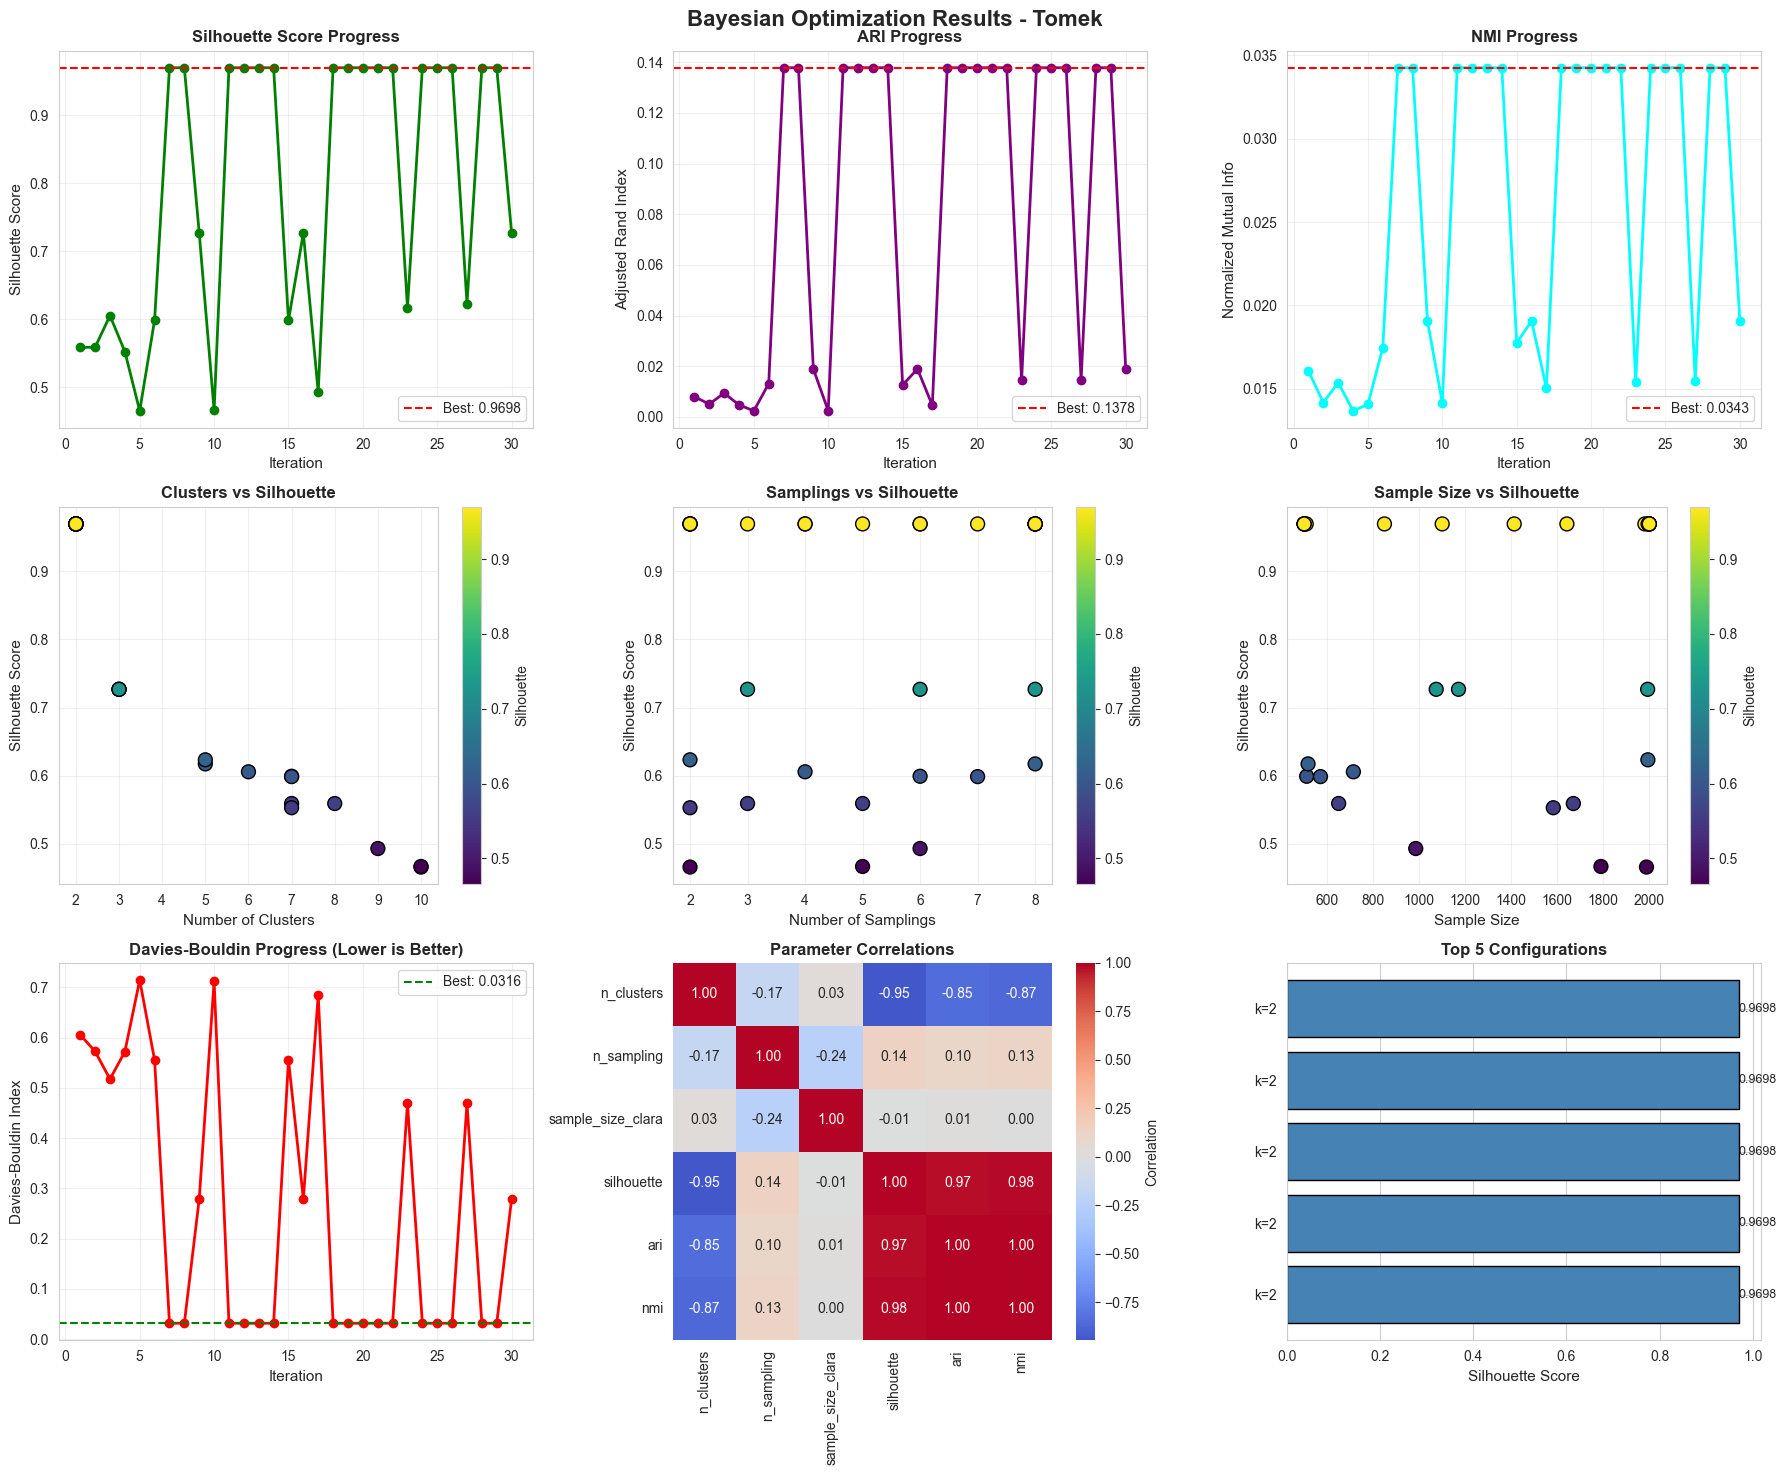


TRAINING FINAL MODEL: Tomek
Fitting on full dataset...

Final Model Metrics:
  Silhouette Score: 0.9693
  Davies-Bouldin Index: 0.0316
  Calinski-Harabasz Score: 1358295.6652
  Inertia: 11229966.4306
  Adjusted Rand Index: 0.1080
  Normalized Mutual Info: 0.0228
  Fowlkes-Mallows Score: 0.8967

Model saved to 'clara_model_tomek.pkl'

PROCESSING: SMOTE-Tomek

BAYESIAN OPTIMIZATION: SMOTE-Tomek
Sampling 3000 points for optimization...

Starting Bayesian Optimization with 30 iterations...

Iteration 1:
  n_clusters=8, n_sampling=3, sample_size=1670
  Silhouette: 0.5667, ARI: 0.0322, NMI: 0.0498

Iteration 2:
  n_clusters=7, n_sampling=5, sample_size=650
  Silhouette: 0.5740, ARI: 0.0390, NMI: 0.0502

Iteration 3:
  n_clusters=6, n_sampling=4, sample_size=714
  Silhouette: 0.5572, ARI: 0.0350, NMI: 0.0444

Iteration 4:
  n_clusters=7, n_sampling=2, sample_size=1583
  Silhouette: 0.5824, ARI: 0.0358, NMI: 0.0470

Iteration 5:
  n_clusters=10, n_sampling=2, sample_size=1988
  Silhouette: 0.

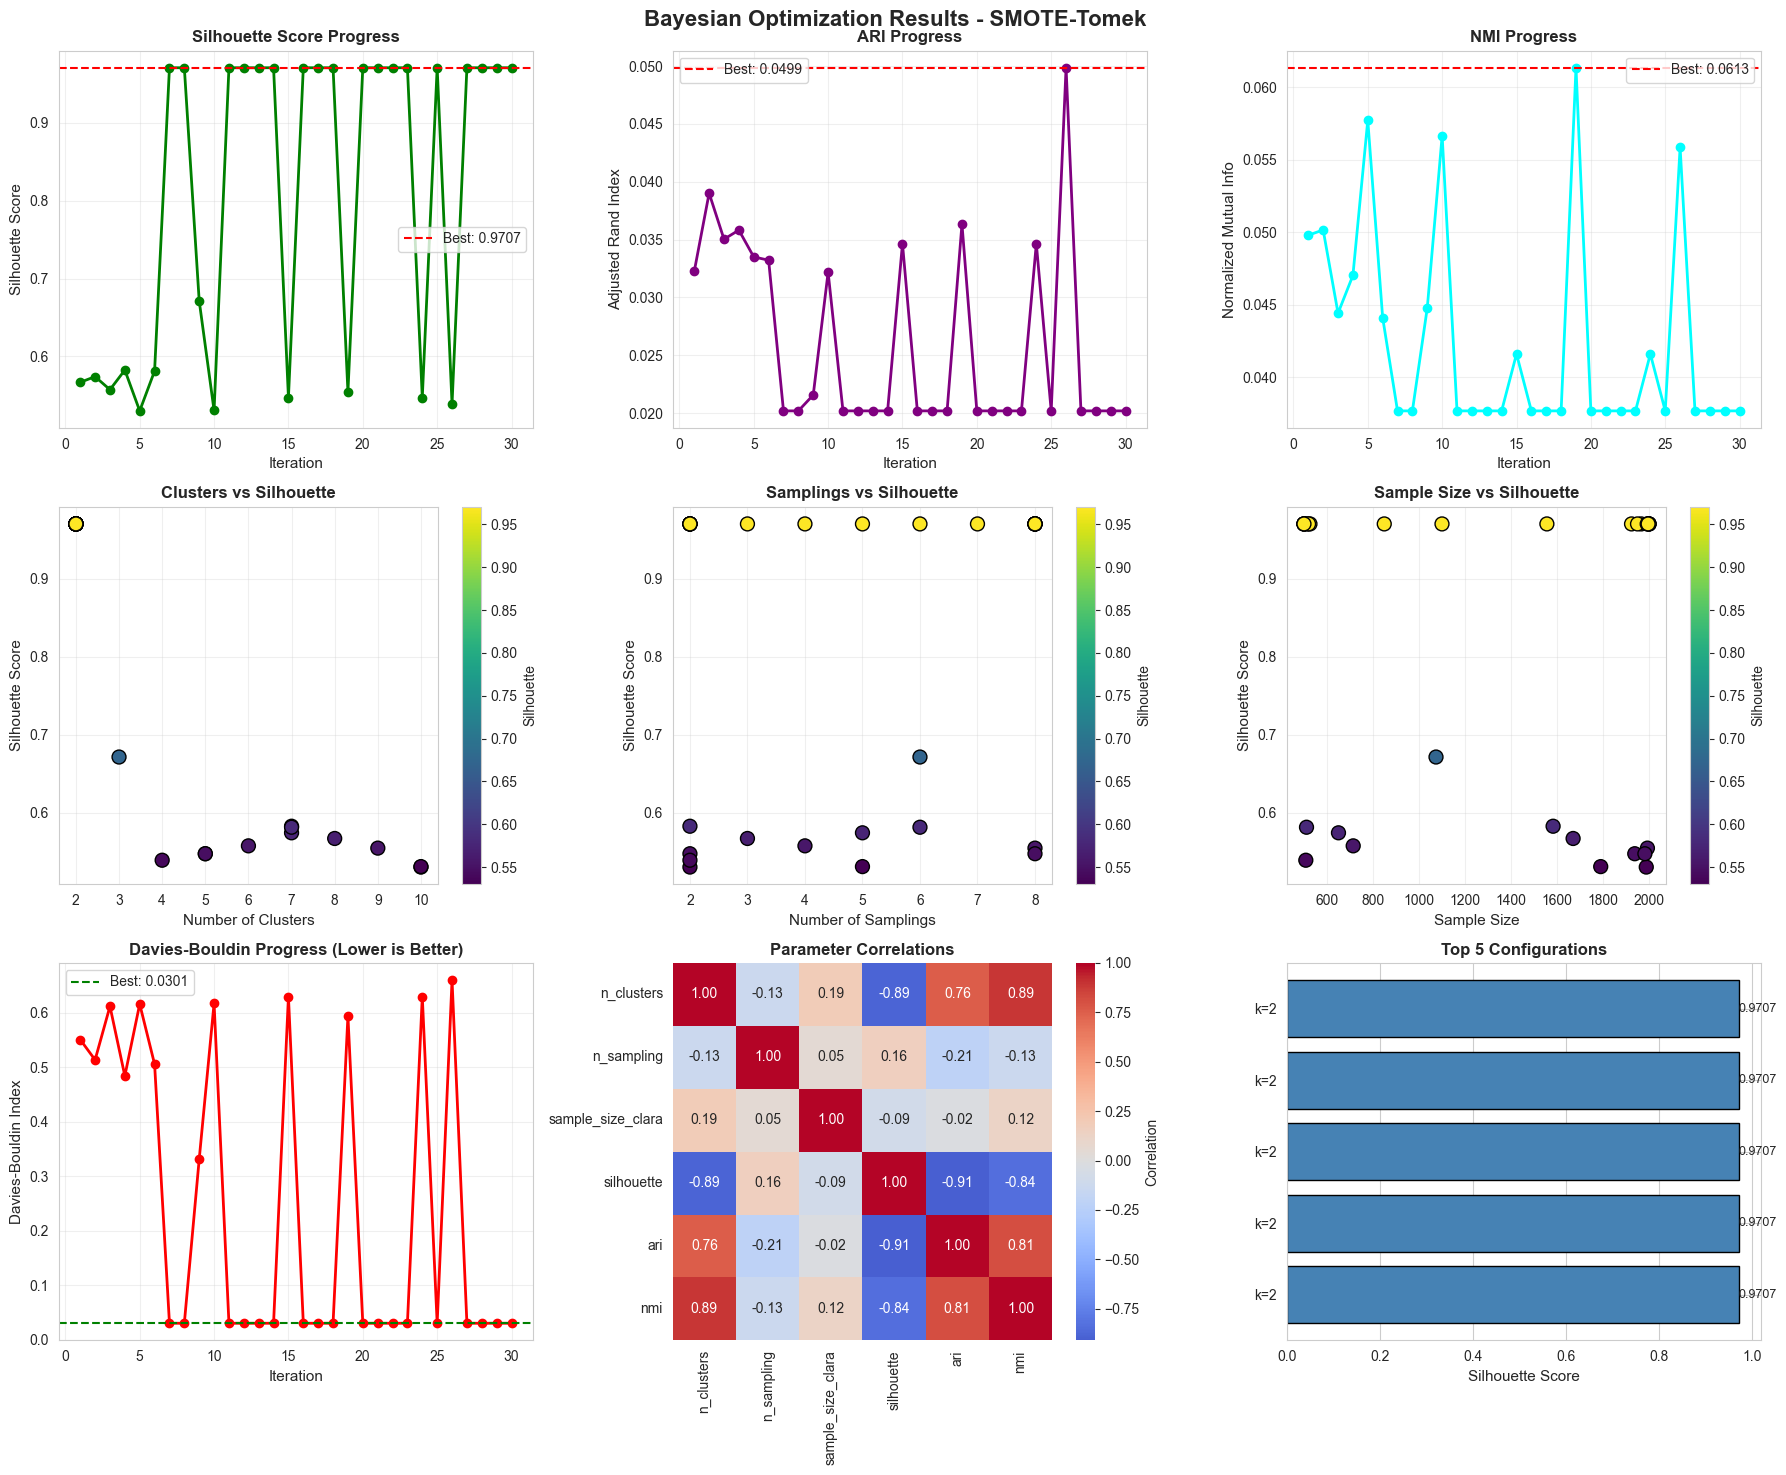


TRAINING FINAL MODEL: SMOTE-Tomek
Fitting on full dataset...

Final Model Metrics:
  Silhouette Score: 0.9710
  Davies-Bouldin Index: 0.0300
  Calinski-Harabasz Score: 4600914.9585
  Inertia: 19373292.6661
  Adjusted Rand Index: 0.0152
  Normalized Mutual Info: 0.0351
  Fowlkes-Mallows Score: 0.6335

Model saved to 'clara_model_smote-tomek.pkl'

COMPARING ALL DATASETS

              Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Score  \
SMOTE                0.970964              0.030009             4.629781e+06   
Tomek                0.969346              0.031577             1.358296e+06   
SMOTE-Tomek          0.970994              0.029986             4.600915e+06   

                  Inertia  Adjusted Rand Index  Normalized Mutual Info  \
SMOTE        1.960193e+07             0.014874                0.034501   
Tomek        1.122997e+07             0.108034                0.022813   
SMOTE-Tomek  1.937329e+07             0.015174                0.035063   

        

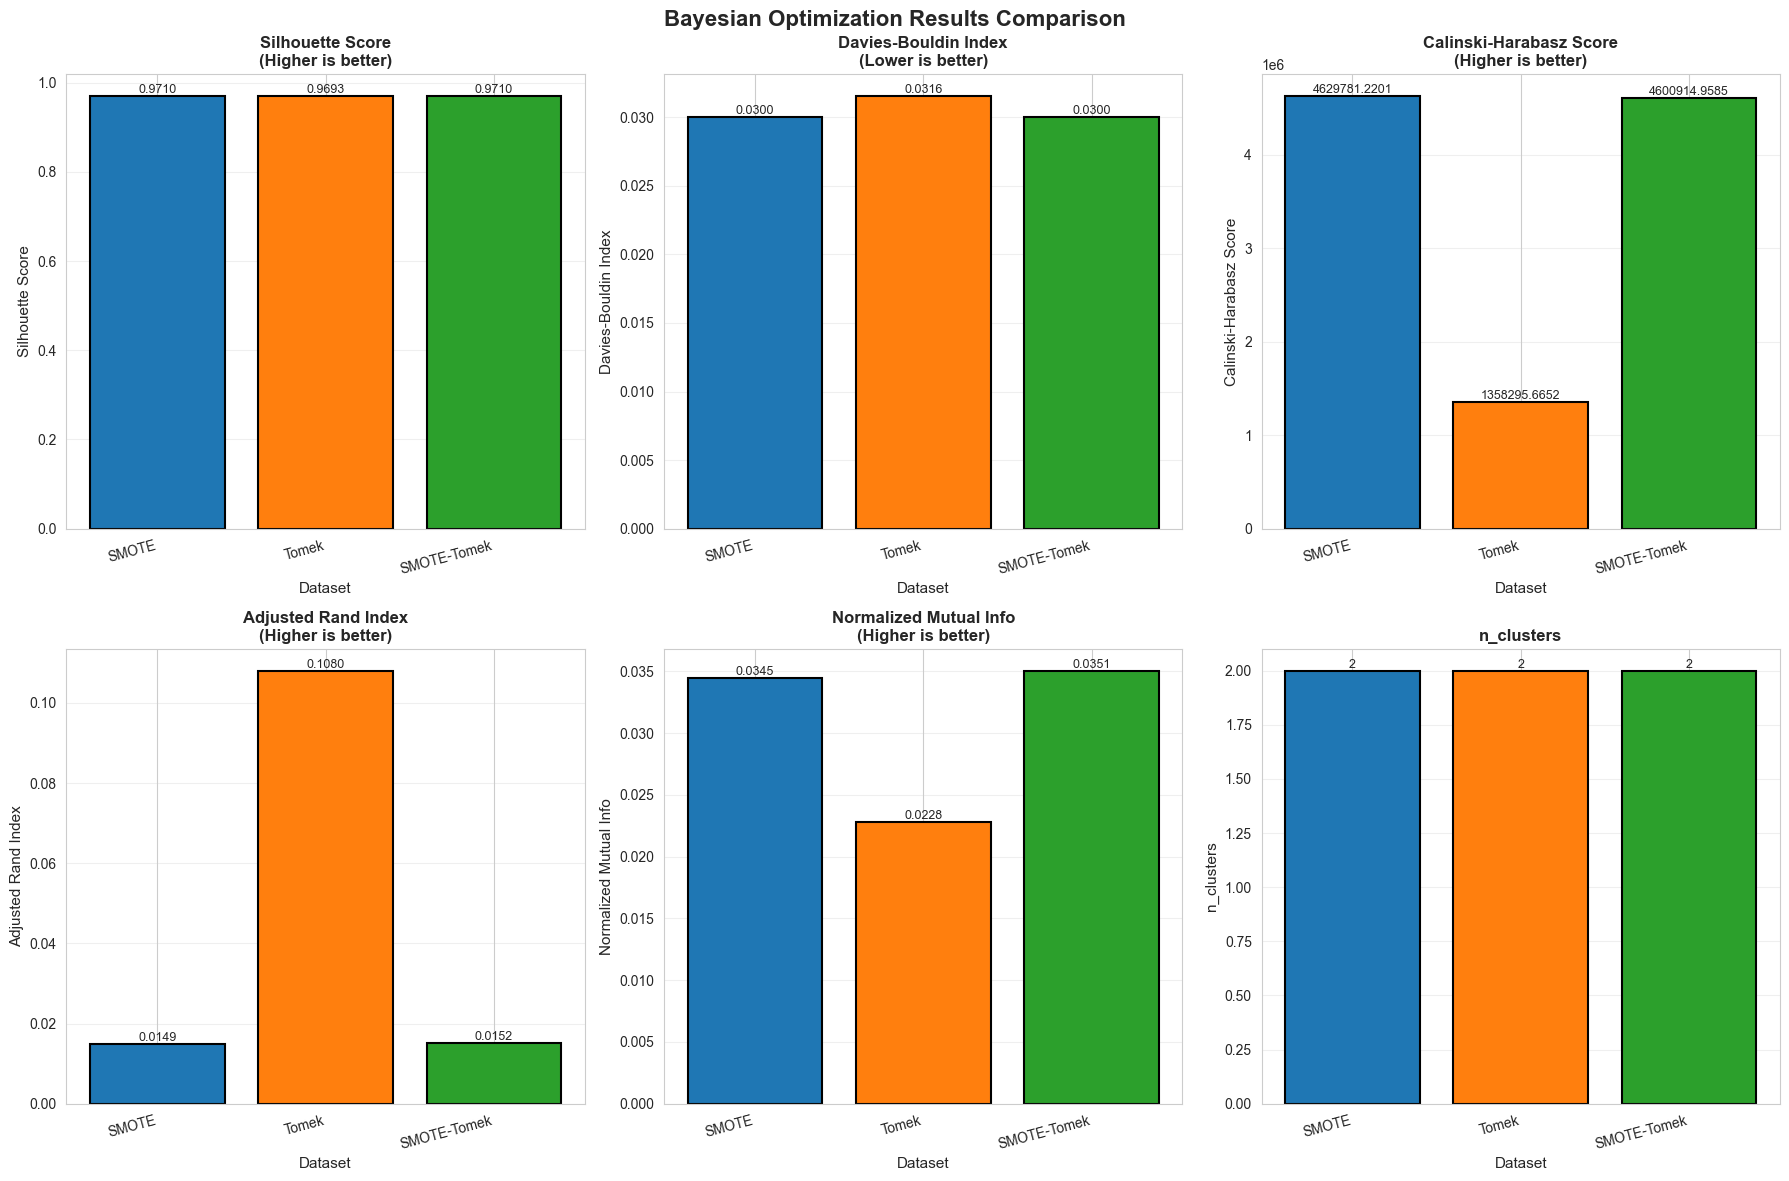


BAYESIAN OPTIMIZATION COMPLETE

All results have been saved:
  - Optimization plots: bayesian_optimization_[dataset].png
  - Detailed results: bayesian_results_[dataset].csv
  - Trained models: clara_model_[dataset].pkl
  - Comparison: bayesian_comparison_all_datasets.png
  - Summary: bayesian_optimization_comparison.csv


In [13]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)
from sklearn.model_selection import cross_val_score
from sklearn_extra.cluster import KMedoids
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from skopt import gp_minimize
from skopt.utils import use_named_args
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Get the Code directory (project root)
current_dir = Path.cwd()
code_dir = current_dir.parent.parent.parent.parent
print(f"Code directory: {code_dir}")

# Define all data paths
PATHS = {
    'X_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote.parquet',
    'X_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_tomek.parquet',
    'X_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote_tomek.parquet',
    'y_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote' / 'y_smote.pkl',
    'y_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'tomek' / 'y_tomek.pkl',
    'y_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote_tomek' / 'y_smote_tomek.pkl',
}

class CLARA:
    """CLARA (Clustering Large Applications) - Memory-efficient K-Medoids"""
    def __init__(self, n_clusters, n_sampling=5, sample_size=1000, random_state=42):
        self.n_clusters = n_clusters
        self.n_sampling = n_sampling
        self.sample_size = sample_size
        self.random_state = random_state
        self.best_medoid_indices_ = None
        self.labels_ = None
        self.inertia_ = None
        
    def fit(self, X, y=None):
        """Fit CLARA algorithm"""
        np.random.seed(self.random_state)
        best_cost = np.inf
        
        # Convert to numpy array and ensure float64
        if isinstance(X, pd.DataFrame):
            X_array = X.values.astype(np.float64)
        else:
            X_array = np.asarray(X, dtype=np.float64)
        
        for i in range(self.n_sampling):
            # Sample data
            sample_idx = np.random.choice(len(X_array), 
                                         min(self.sample_size, len(X_array)), 
                                         replace=False)
            X_sample = X_array[sample_idx]
            
            # Run K-Medoids on sample
            kmedoids = KMedoids(
                n_clusters=self.n_clusters,
                metric='euclidean',
                method='pam',
                init='k-medoids++',
                max_iter=300,
                random_state=self.random_state + i
            )
            kmedoids.fit(X_sample)
            
            # Get medoids from sample
            sample_medoid_indices = kmedoids.medoid_indices_
            medoids = X_sample[sample_medoid_indices].astype(np.float64)
            
            # Assign all data points to nearest medoid using chunked processing
            labels = np.zeros(len(X_array), dtype=np.int32)
            min_distances = np.full(len(X_array), np.inf, dtype=np.float64)
            
            chunk_size = 5000
            for start_idx in range(0, len(X_array), chunk_size):
                end_idx = min(start_idx + chunk_size, len(X_array))
                X_chunk = X_array[start_idx:end_idx]
                
                # Calculate distances for this chunk
                chunk_distances = np.zeros((len(X_chunk), self.n_clusters), dtype=np.float64)
                for j, medoid in enumerate(medoids):
                    diff = X_chunk - medoid
                    chunk_distances[:, j] = np.sqrt(np.sum(diff ** 2, axis=1))
                
                labels[start_idx:end_idx] = np.argmin(chunk_distances, axis=1)
                min_distances[start_idx:end_idx] = np.min(chunk_distances, axis=1)
            
            cost = np.sum(min_distances)
            
            # Update best solution
            if cost < best_cost:
                best_cost = cost
                self.best_medoid_indices_ = []
                for medoid in medoids:
                    diff = X_array - medoid
                    distances_to_medoid = np.sqrt(np.sum(diff ** 2, axis=1))
                    self.best_medoid_indices_.append(np.argmin(distances_to_medoid))
                self.labels_ = labels.copy()
                self.inertia_ = cost
        
        self.best_medoid_indices_ = np.array(self.best_medoid_indices_)
        return self
    
    def fit_predict(self, X, y=None):
        """Fit and return labels"""
        self.fit(X, y)
        return self.labels_
    
    def score(self, X, y=None):
        """Return silhouette score (for optimization)"""
        if self.labels_ is None:
            self.fit(X, y)
        return silhouette_score(X, self.labels_)
    
    @property
    def medoid_indices_(self):
        return self.best_medoid_indices_

def load_all_data():
    """Load all data files"""
    data = {}
    print("\n" + "="*50)
    print("LOADING DATA")
    print("="*50)
    
    parquet_keys = ['X_train_smote', 'X_train_tomek', 'X_train_smote_tomek']
    for key in parquet_keys:
        path = PATHS[key]
        if path.exists():
            try:
                data[key] = pd.read_parquet(path)
                print(f"✓ Loaded {key}: {data[key].shape}")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
    
    pickle_keys = ['y_train_smote', 'y_train_tomek', 'y_train_smote_tomek']
    for key in pickle_keys:
        path = PATHS[key]
        if path.exists():
            try:
                with open(path, 'rb') as f:
                    data[key] = pickle.load(f)
                print(f"✓ Loaded {key}: {len(data[key])} samples")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
    
    return data

def bayesian_optimization_kmedoids(X, y_true, dataset_name='Dataset', n_calls=30, sample_size=3000):
    """
    Perform Bayesian Optimization to find optimal K-Medoids hyperparameters
    
    Parameters:
    -----------
    X : array-like
        Training data
    y_true : array-like
        True labels (for evaluation)
    dataset_name : str
        Name of the dataset
    n_calls : int
        Number of optimization iterations
    sample_size : int
        Size of data sample for faster optimization
    """
    print("\n" + "="*50)
    print(f"BAYESIAN OPTIMIZATION: {dataset_name}")
    print("="*50)
    
    # Sample data for faster optimization
    if len(X) > sample_size:
        print(f"Sampling {sample_size} points for optimization...")
        sample_idx = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X.iloc[sample_idx] if isinstance(X, pd.DataFrame) else X[sample_idx]
        y_sample = y_true.iloc[sample_idx] if isinstance(y_true, pd.Series) else y_true[sample_idx]
    else:
        X_sample = X
        y_sample = y_true
    
    # Convert to numpy
    X_array = X_sample.values if isinstance(X_sample, pd.DataFrame) else X_sample
    X_array = X_array.astype(np.float64)
    
    # Define search space
    search_space = [
        Integer(2, 10, name='n_clusters'),
        Integer(2, 8, name='n_sampling'),
        Integer(500, 2000, name='sample_size_clara')
    ]
    
    # Store results
    iteration_results = []
    
    @use_named_args(search_space)
    def objective(n_clusters, n_sampling, sample_size_clara):
        """Objective function to minimize (negative silhouette score)"""
        try:
            # Create CLARA instance
            clara = CLARA(
                n_clusters=n_clusters,
                n_sampling=n_sampling,
                sample_size=sample_size_clara,
                random_state=42
            )
            
            # Fit the model
            labels = clara.fit_predict(X_array)
            
            # Calculate multiple metrics
            silhouette = silhouette_score(X_array, labels)
            davies_bouldin = davies_bouldin_score(X_array, labels)
            calinski = calinski_harabasz_score(X_array, labels)
            ari = adjusted_rand_score(y_sample, labels)
            nmi = normalized_mutual_info_score(y_sample, labels)
            
            # Store results
            result = {
                'n_clusters': n_clusters,
                'n_sampling': n_sampling,
                'sample_size_clara': sample_size_clara,
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin,
                'calinski_harabasz': calinski,
                'ari': ari,
                'nmi': nmi,
                'inertia': clara.inertia_
            }
            iteration_results.append(result)
            
            print(f"\nIteration {len(iteration_results)}:")
            print(f"  n_clusters={n_clusters}, n_sampling={n_sampling}, sample_size={sample_size_clara}")
            print(f"  Silhouette: {silhouette:.4f}, ARI: {ari:.4f}, NMI: {nmi:.4f}")
            
            # Return negative silhouette (we minimize, but want to maximize silhouette)
            return -silhouette
            
        except Exception as e:
            print(f"Error in iteration: {e}")
            return 0.0  # Return neutral score on error
    
    # Run Bayesian Optimization
    print(f"\nStarting Bayesian Optimization with {n_calls} iterations...")
    result = gp_minimize(
        objective,
        search_space,
        n_calls=n_calls,
        random_state=42,
        verbose=False,
        n_jobs=1
    )
    
    # Extract best parameters
    best_params = {
        'n_clusters': result.x[0],
        'n_sampling': result.x[1],
        'sample_size_clara': result.x[2],
        'best_score': -result.fun  # Convert back to positive
    }
    
    print("\n" + "="*50)
    print("OPTIMIZATION COMPLETE")
    print("="*50)
    print(f"\nBest Parameters:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(iteration_results)
    
    return best_params, results_df, result

def plot_optimization_results(results_df, dataset_name, save_path=None):
    """Plot Bayesian Optimization results"""
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle(f'Bayesian Optimization Results - {dataset_name}', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: Silhouette Score over iterations
    ax = axes[0, 0]
    ax.plot(results_df.index + 1, results_df['silhouette'], 
            marker='o', linewidth=2, markersize=6, color='green')
    ax.axhline(results_df['silhouette'].max(), color='red', 
               linestyle='--', label=f'Best: {results_df["silhouette"].max():.4f}')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.set_title('Silhouette Score Progress', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: ARI over iterations
    ax = axes[0, 1]
    ax.plot(results_df.index + 1, results_df['ari'], 
            marker='o', linewidth=2, markersize=6, color='purple')
    ax.axhline(results_df['ari'].max(), color='red', 
               linestyle='--', label=f'Best: {results_df["ari"].max():.4f}')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Adjusted Rand Index', fontsize=11)
    ax.set_title('ARI Progress', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: NMI over iterations
    ax = axes[0, 2]
    ax.plot(results_df.index + 1, results_df['nmi'], 
            marker='o', linewidth=2, markersize=6, color='cyan')
    ax.axhline(results_df['nmi'].max(), color='red', 
               linestyle='--', label=f'Best: {results_df["nmi"].max():.4f}')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Normalized Mutual Info', fontsize=11)
    ax.set_title('NMI Progress', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: n_clusters vs Silhouette
    ax = axes[1, 0]
    scatter = ax.scatter(results_df['n_clusters'], results_df['silhouette'], 
                        c=results_df['silhouette'], cmap='viridis', 
                        s=100, edgecolors='black', linewidth=1)
    ax.set_xlabel('Number of Clusters', fontsize=11)
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.set_title('Clusters vs Silhouette', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Silhouette')
    ax.grid(True, alpha=0.3)
    
    # Plot 5: n_sampling vs Silhouette
    ax = axes[1, 1]
    scatter = ax.scatter(results_df['n_sampling'], results_df['silhouette'], 
                        c=results_df['silhouette'], cmap='viridis', 
                        s=100, edgecolors='black', linewidth=1)
    ax.set_xlabel('Number of Samplings', fontsize=11)
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.set_title('Samplings vs Silhouette', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Silhouette')
    ax.grid(True, alpha=0.3)
    
    # Plot 6: sample_size vs Silhouette
    ax = axes[1, 2]
    scatter = ax.scatter(results_df['sample_size_clara'], results_df['silhouette'], 
                        c=results_df['silhouette'], cmap='viridis', 
                        s=100, edgecolors='black', linewidth=1)
    ax.set_xlabel('Sample Size', fontsize=11)
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.set_title('Sample Size vs Silhouette', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Silhouette')
    ax.grid(True, alpha=0.3)
    
    # Plot 7: Davies-Bouldin over iterations
    ax = axes[2, 0]
    ax.plot(results_df.index + 1, results_df['davies_bouldin'], 
            marker='o', linewidth=2, markersize=6, color='red')
    ax.axhline(results_df['davies_bouldin'].min(), color='green', 
               linestyle='--', label=f'Best: {results_df["davies_bouldin"].min():.4f}')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Davies-Bouldin Index', fontsize=11)
    ax.set_title('Davies-Bouldin Progress (Lower is Better)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 8: Parameter correlation heatmap
    ax = axes[2, 1]
    param_cols = ['n_clusters', 'n_sampling', 'sample_size_clara', 'silhouette', 'ari', 'nmi']
    corr_matrix = results_df[param_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Parameter Correlations', fontsize=12, fontweight='bold')
    
    # Plot 9: Top 5 configurations
    ax = axes[2, 2]
    top_5 = results_df.nlargest(5, 'silhouette')[['n_clusters', 'silhouette']].reset_index(drop=True)
    bars = ax.barh(range(len(top_5)), top_5['silhouette'], color='steelblue', edgecolor='black')
    ax.set_yticks(range(len(top_5)))
    ax.set_yticklabels([f"k={int(k)}" for k in top_5['n_clusters']])
    ax.set_xlabel('Silhouette Score', fontsize=11)
    ax.set_title('Top 5 Configurations', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2., 
               f'{width:.4f}', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def train_final_model(X, y_true, best_params, dataset_name):
    """Train final model with best parameters on full dataset"""
    print("\n" + "="*50)
    print(f"TRAINING FINAL MODEL: {dataset_name}")
    print("="*50)
    
    # Create CLARA with best parameters
    clara = CLARA(
        n_clusters=best_params['n_clusters'],
        n_sampling=best_params['n_sampling'],
        sample_size=best_params['sample_size_clara'],
        random_state=42
    )
    
    # Train on full dataset
    print("Fitting on full dataset...")
    labels = clara.fit_predict(X)
    
    # Calculate final metrics
    metrics = {
        'Silhouette Score': silhouette_score(X, labels),
        'Davies-Bouldin Index': davies_bouldin_score(X, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(X, labels),
        'Inertia': clara.inertia_,
        'Adjusted Rand Index': adjusted_rand_score(y_true, labels),
        'Normalized Mutual Info': normalized_mutual_info_score(y_true, labels),
        'Fowlkes-Mallows Score': fowlkes_mallows_score(y_true, labels)
    }
    
    print("\nFinal Model Metrics:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    
    return clara, labels, metrics

def compare_all_datasets(all_results):
    """Compare results across all datasets"""
    print("\n" + "="*50)
    print("COMPARING ALL DATASETS")
    print("="*50)
    
    comparison_df = pd.DataFrame(all_results).T
    print("\n", comparison_df)
    
    # Save to CSV
    comparison_df.to_csv('bayesian_optimization_comparison.csv')
    print("\nComparison saved to 'bayesian_optimization_comparison.csv'")
    
    # Plot comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Bayesian Optimization Results Comparison', 
                 fontsize=16, fontweight='bold')
    
    metrics_to_plot = [
        ('Silhouette Score', 'higher'),
        ('Davies-Bouldin Index', 'lower'),
        ('Calinski-Harabasz Score', 'higher'),
        ('Adjusted Rand Index', 'higher'),
        ('Normalized Mutual Info', 'higher'),
        ('n_clusters', 'value')
    ]
    
    for idx, (metric, direction) in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]
        values = comparison_df[metric]
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        bars = ax.bar(range(len(values)), values, color=colors, 
                     edgecolor='black', linewidth=1.5)
        ax.set_xlabel('Dataset', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        title = f'{metric}'
        if direction != 'value':
            title += f'\n({direction.capitalize()} is better)'
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(values)))
        ax.set_xticklabels(values.index, rotation=15, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}' if metric != 'n_clusters' else f'{int(height)}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('bayesian_comparison_all_datasets.png', dpi=300, bbox_inches='tight')
    plt.show()

# Main execution
if __name__ == "__main__":
    # Load data
    data = load_all_data()
    
    if not data:
        print("No data loaded. Exiting.")
        exit()
    
    # Define datasets to analyze
    datasets = [
        ('X_train_smote', 'y_train_smote', 'SMOTE'),
        ('X_train_tomek', 'y_train_tomek', 'Tomek'),
        ('X_train_smote_tomek', 'y_train_smote_tomek', 'SMOTE-Tomek')
    ]
    
    all_results = {}
    
    for X_key, y_key, name in datasets:
        if X_key in data and y_key in data:
            X = data[X_key]
            y = data[y_key]
            
            print(f"\n{'='*60}")
            print(f"PROCESSING: {name}")
            print(f"{'='*60}")
            
            # Perform Bayesian Optimization
            best_params, results_df, opt_result = bayesian_optimization_kmedoids(
                X, y, 
                dataset_name=name,
                n_calls=30,  # Adjust based on computational budget
                sample_size=3000
            )
            
            # Plot optimization results
            plot_optimization_results(
                results_df, 
                name, 
                save_path=f'bayesian_optimization_{name.lower()}.png'
            )
            
            # Save optimization results
            results_df.to_csv(f'bayesian_results_{name.lower()}.csv', index=False)
            
            # Train final model with best parameters
            model, labels, metrics = train_final_model(X, y, best_params, name)
            
            # Store results with best parameters
            metrics['n_clusters'] = best_params['n_clusters']
            metrics['n_sampling'] = best_params['n_sampling']
            metrics['sample_size_clara'] = best_params['sample_size_clara']
            all_results[name] = metrics
            
            # Save model
            with open(f'clara_model_{name.lower()}.pkl', 'wb') as f:
                pickle.dump(model, f)
            print(f"\nModel saved to 'clara_model_{name.lower()}.pkl'")
    
    # Compare all datasets
    if all_results:
        compare_all_datasets(all_results)
    
    print("\n" + "="*60)
    print("BAYESIAN OPTIMIZATION COMPLETE")
    print("="*60)
    print("\nAll results have been saved:")
    print("  - Optimization plots: bayesian_optimization_[dataset].png")
    print("  - Detailed results: bayesian_results_[dataset].csv")
    print("  - Trained models: clara_model_[dataset].pkl")
    print("  - Comparison: bayesian_comparison_all_datasets.png")
    print("  - Summary: bayesian_optimization_comparison.csv")